# ⚽ FIFA World Cup 2026 — Player Performance Analysis

> **Dataset:** `fifa_world_cup_2026_player_performance.csv`  
> **Tujuan:** Mengekstrak insight mendalam dari performa pemain selama turnamen FIFA World Cup 2026  

---

## 📋 Daftar Isi
1. [Setup & Data Loading](#1)
2. [Data Overview & Quality Check](#2)
3. [Tournament Overview](#3)
4. [Player Demographics](#4)
5. [Attacking Performance](#5)
6. [Passing & Creativity](#6)
7. [Defensive Performance](#7)
8. [Physical & Stamina](#8)
9. [Overall Player Ratings](#9)
10. [Team Analysis](#10)
11. [Advanced Insights](#11)
12. [Key Findings & Summary](#12)


---
## 1. Setup & Data Loading <a id='1'></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# ── Visual Theme ────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',
    'axes.labelcolor': '#e6edf3',
    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'text.color': '#e6edf3',
    'grid.color': '#21262d',
    'grid.linestyle': '--',
    'grid.alpha': 0.6,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.labelsize': 11,
    'legend.facecolor': '#161b22',
    'legend.edgecolor': '#30363d',
})

PALETTE_MAIN = ['#58a6ff', '#3fb950', '#f78166', '#d2a8ff', '#ffa657', '#79c0ff', '#56d364']
COLOR_GOLD   = '#ffd700'
COLOR_GREEN  = '#3fb950'
COLOR_BLUE   = '#58a6ff'
COLOR_RED    = '#f78166'
COLOR_PURPLE = '#d2a8ff'

pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', '{:.2f}'.format)

print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


In [2]:
# ── Load Dataset ─────────────────────────────────────────────────────────────
FILE_PATH = 'fifa_world_cup_2026_player_performance.csv'
df = pd.read_csv(FILE_PATH)
df['match_date'] = pd.to_datetime(df['match_date'])

print(f'🗂️  Dataset berhasil dimuat!')
print(f'   Jumlah Baris   : {df.shape[0]:,}')
print(f'   Jumlah Kolom   : {df.shape[1]}')
df.head()

🗂️  Dataset berhasil dimuat!
   Jumlah Baris   : 54,600
   Jumlah Kolom   : 75


,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,club_name,market_value_eur,match_id,match_date,stadium,city,opponent_team,tournament_stage,match_result,goals_team,goals_opponent,minutes_played,goals,assists,shots,shots_on_target,expected_goals_xg,expected_assists_xa,key_passes,successful_passes,total_passes,pass_accuracy,dribbles_attempted,successful_dribbles,crosses,successful_crosses,tackles,interceptions,clearances,blocks,aerial_duels_won,aerial_duels_lost,recoveries,defensive_actions,fouls_committed,fouls_suffered,yellow_cards,red_cards,offsides,saves,save_percentage,punches,clean_sheet,goals_conceded,penalty_saves,distance_covered_km,sprint_distance_km,top_speed_kmh,accelerations,decelerations,stamina_score,player_rating,performance_score,offensive_contribution,defensive_contribution,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,P00055,Rodri Fati,26,Spanish,Spain,3,Goalkeeper,195,75,Left,RB Salzburg,4384884,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,72,0,0,0,0,0.00,0.00,0,15,26,0.59,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,4,0.83,0,1,0,0,7.80,0.70,26.50,13,23,81.90,5.60,50.90,3.30,48.20,1.10,44.20,55.90,42.00,51.80,0,0,242,0,5.80
1,P00070,Ansu Le Normand,19,Spanish,Spain,18,Midfielder,178,75,Right,Chelsea,4918927,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,90,0,0,0,0,0.01,0.00,1,35,40,0.89,1,0,1,0,0,1,3,1,2,0,2,5,0,1,0,0,0,0,0.00,0,0,0,0,10.40,1.10,29.00,19,17,85.50,5.70,55.90,37.90,29.40,3.50,38.20,43.70,31.10,52.70,0,3,342,0,5.50
2,P00066,Gavi Ramos,18,Spanish,Spain,14,Midfielder,177,72,Left,AIK,125015698,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,73,1,0,2,0,0.08,0.07,2,72,85,0.85,0,0,3,0,1,1,0,0,1,2,4,2,0,0,0,0,0,0,0.00,0,0,0,0,8.80,1.30,33.70,30,19,88.80,8.30,82.90,79.80,78.60,15.30,99.00,99.00,83.40,54.80,1,1,245,0,8.40
3,P00073,Pedro Cubarsi,20,Spanish,Spain,21,Forward,182,74,Right,PSV Eindhoven,11805512,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,80,1,1,5,2,0.00,0.21,0,12,19,0.67,1,0,0,0,1,1,1,0,3,0,1,3,0,1,0,0,0,0,0.00,0,0,0,0,9.60,1.00,32.10,26,19,89.20,6.90,67.50,47.30,6.90,1.20,19.80,42.30,40.90,78.50,5,3,422,0,6.70
4,P00059,Alvaro Oyarzabal,23,Spanish,Spain,7,Defender,191,81,Left,Juventus,13325174,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,79,0,0,1,0,0.00,0.00,1,33,44,0.76,2,1,0,0,1,3,0,2,1,2,4,6,0,0,0,0,0,0,0.00,0,0,0,0,7.50,0.70,30.50,23,18,73.60,5.70,55.40,33.00,75.60,6.20,44.10,33.50,60.00,56.60,0,0,440,0,5.70


---
## 2. Data Overview & Quality Check <a id='2'></a>

In [3]:
# ── Basic Info ───────────────────────────────────────────────────────────────
print('📊 INFORMASI DATASET')
print('='*60)
print(f'  Total Baris        : {df.shape[0]:,}')
print(f'  Total Kolom        : {df.shape[1]}')
print(f'  Ukuran Memory      : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print(f'  Rentang Tanggal    : {df["match_date"].min().date()} → {df["match_date"].max().date()}')
print()
print('🔍 TIPE DATA KOLOM')
print('-'*60)
df.dtypes.value_counts()

📊 INFORMASI DATASET
  Total Baris        : 54,600
  Total Kolom        : 75
  Ukuran Memory      : 67.8 MB
  Rentang Tanggal    : 2026-06-11 → 2026-07-31

🔍 TIPE DATA KOLOM
------------------------------------------------------------


int64             43
float64           18
str               13
datetime64[us]     1
Name: count, dtype: int64

In [4]:
# ── Missing Values Check ─────────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if len(missing_df) > 0:
    print('⚠️  Kolom dengan Missing Values:')
    display(missing_df)
else:
    print('✅ Dataset bersih — tidak ada missing values!')

dupe_count = df.duplicated().sum()
print(f'\n🔁 Duplikat baris : {dupe_count}')

✅ Dataset bersih — tidak ada missing values!

🔁 Duplikat baris : 0


In [5]:
# ── Descriptive Statistics ───────────────────────────────────────────────────
key_cols = [
    'age', 'minutes_played', 'goals', 'assists', 'expected_goals_xg',
    'pass_accuracy', 'shots', 'tackles', 'player_rating',
    'performance_score', 'top_speed_kmh', 'distance_covered_km'
]
df[key_cols].describe().T.style.background_gradient(cmap='Blues', subset=['mean', '50%', 'max'])

,count,mean,std,min,25%,50%,75%,max
age,54600.000000,26.296484,4.067519,17.000000,23.000000,26.000000,29.000000,39.000000
minutes_played,54600.000000,36.199817,36.419755,0.000000,0.000000,24.000000,75.000000,90.000000
goals,54600.000000,0.055385,0.251900,0.000000,0.000000,0.000000,0.000000,4.000000
assists,54600.000000,0.052363,0.239021,0.000000,0.000000,0.000000,0.000000,3.000000
expected_goals_xg,54600.000000,0.016112,0.074648,0.000000,0.000000,0.000000,0.000000,2.310000
pass_accuracy,54600.000000,0.808440,0.074286,0.420000,0.760000,0.820000,0.860000,0.970000
shots,54600.000000,0.447051,0.947155,0.000000,0.000000,0.000000,1.000000,11.000000
tackles,54600.000000,0.802656,1.343731,0.000000,0.000000,0.000000,1.000000,8.000000
player_rating,54600.000000,3.634700,3.155846,0.000000,0.000000,5.500000,6.400000,9.400000
performance_score,54600.000000,36.828995,31.072667,0.000000,0.700000,54.100000,64.100000,97.700000


---
## 3. Tournament Overview <a id='3'></a>

In [6]:
# ── Tournament Summary ───────────────────────────────────────────────────────
n_teams   = df['team'].nunique()
n_players = df['player_id'].nunique()
n_matches = df['match_id'].nunique()
n_stages  = df['tournament_stage'].nunique()

print('🏆 TOURNAMENT OVERVIEW — FIFA WORLD CUP 2026')
print('='*50)
print(f'  🌍 Total Tim Peserta    : {n_teams}')
print(f'  👤 Total Pemain Unik    : {n_players}')
print(f'  ⚽ Total Pertandingan    : {n_matches}')
print(f'  📅 Total Tahap          : {n_stages}')
print()
stage_counts = df.groupby('tournament_stage')['match_id'].nunique().reset_index()
stage_counts.columns = ['Tahap', 'Jumlah Laga']
print('📋 TAHAPAN TURNAMEN:')
display(stage_counts)

🏆 TOURNAMENT OVERVIEW — FIFA WORLD CUP 2026
  🌍 Total Tim Peserta    : 48
  👤 Total Pemain Unik    : 1248
  ⚽ Total Pertandingan    : 1050
  📅 Total Tahap          : 7

📋 TAHAPAN TURNAMEN:


,Tahap,Jumlah Laga
0,Final,21
1,Group Stage,578
2,Quarter Finals,84
3,Round of 16,126
4,Round of 32,178
5,Semi Finals,42
6,Third Place Match,21


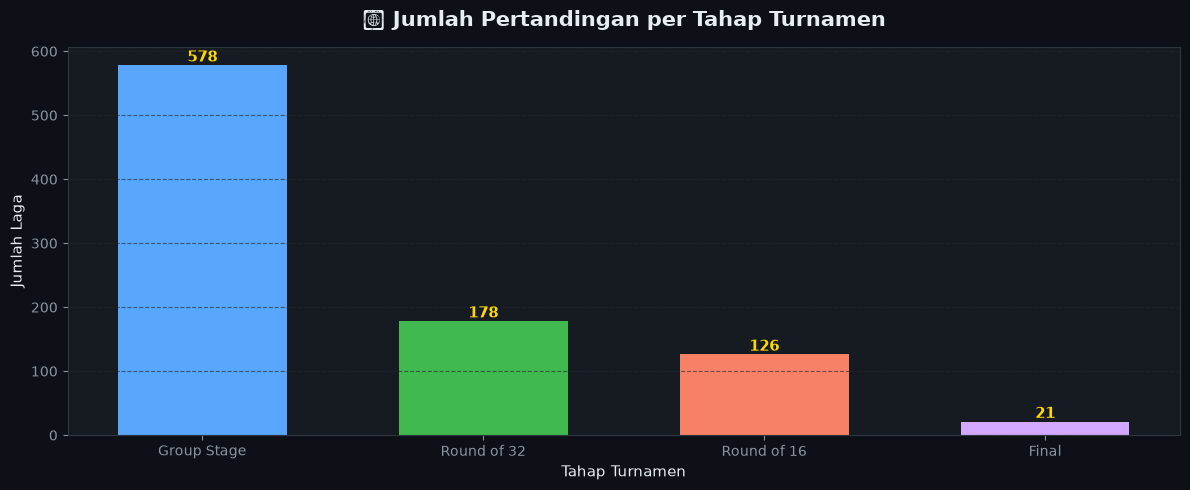

In [7]:
# ── Matches per Stage ────────────────────────────────────────────────────────
STAGE_ORDER = ['Group Stage', 'Round of 32', 'Round of 16', 'Quarter-Final', 'Semi-Final', 'Third Place', 'Final']
stage_cnts  = df.groupby('tournament_stage')['match_id'].nunique()
stage_cnts  = stage_cnts.reindex([s for s in STAGE_ORDER if s in stage_cnts.index])

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(stage_cnts.index, stage_cnts.values,
              color=PALETTE_MAIN[:len(stage_cnts)], edgecolor='none', width=0.6)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=11, fontweight='bold', color=COLOR_GOLD)
ax.set_title('📅 Jumlah Pertandingan per Tahap Turnamen', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Tahap Turnamen')
ax.set_ylabel('Jumlah Laga')
ax.grid(axis='y')
plt.tight_layout()
plt.show()

---
## 4. Player Demographics <a id='4'></a>

📝 Total pemain unik: 1,248


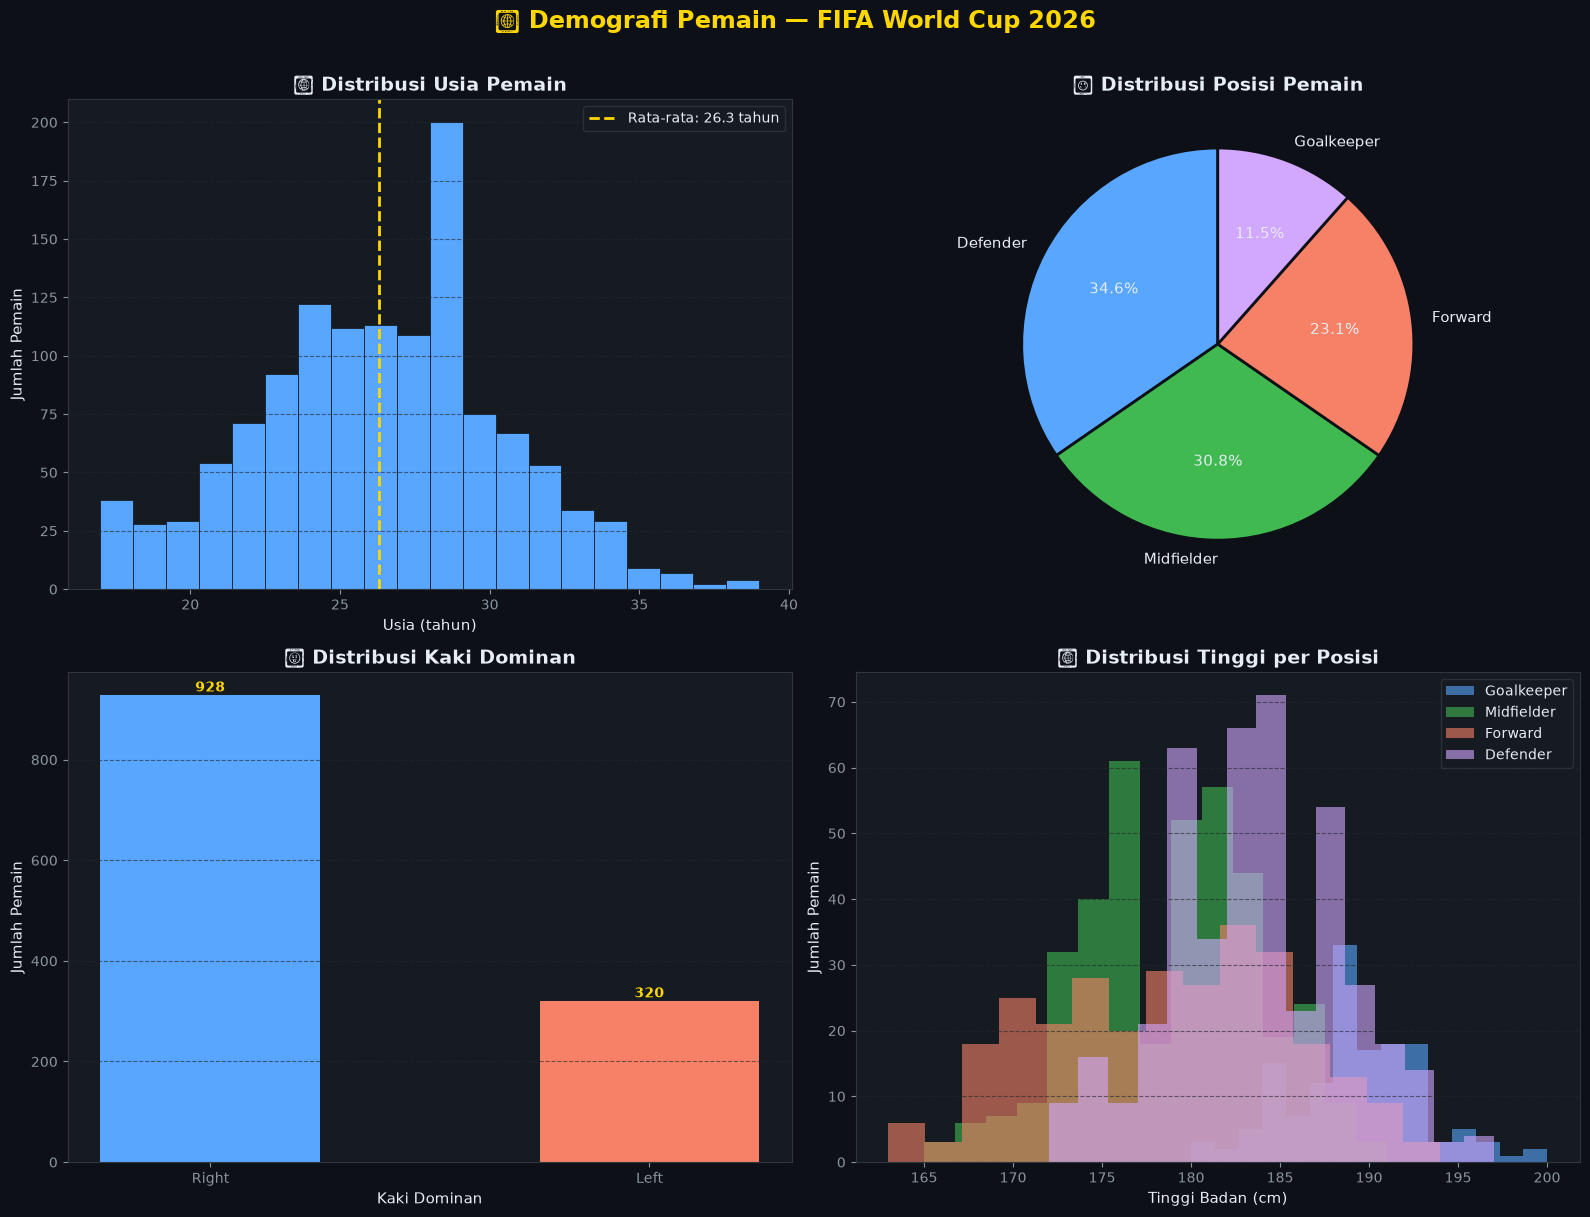

In [8]:
# ── Unique player profiles ───────────────────────────────────────────────────
player_info = df.drop_duplicates(subset='player_id')[[
    'player_id','player_name','age','nationality','team','position',
    'height_cm','weight_kg','preferred_foot','club_name','market_value_eur'
]].copy()

print(f'📝 Total pemain unik: {len(player_info):,}')

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('#0d1117')

# Age Distribution
ax = axes[0, 0]
ax.hist(player_info['age'], bins=20, color=COLOR_BLUE, edgecolor='#0d1117', linewidth=0.5)
ax.axvline(player_info['age'].mean(), color=COLOR_GOLD, linestyle='--', linewidth=2,
           label=f'Rata-rata: {player_info["age"].mean():.1f} tahun')
ax.set_title('📊 Distribusi Usia Pemain', fontweight='bold')
ax.set_xlabel('Usia (tahun)')
ax.set_ylabel('Jumlah Pemain')
ax.legend()
ax.grid(axis='y')

# Position Distribution
ax = axes[0, 1]
pos_counts = player_info['position'].value_counts()
wedge_colors = [COLOR_BLUE, COLOR_GREEN, COLOR_RED, COLOR_PURPLE]
ax.pie(pos_counts.values, labels=pos_counts.index,
       colors=wedge_colors[:len(pos_counts)],
       autopct='%1.1f%%', startangle=90,
       textprops={'color': '#e6edf3', 'fontsize': 11},
       wedgeprops={'edgecolor': '#0d1117', 'linewidth': 2})
ax.set_title('⚽ Distribusi Posisi Pemain', fontweight='bold')

# Preferred Foot
ax = axes[1, 0]
foot_counts = player_info['preferred_foot'].value_counts()
ax.bar(foot_counts.index, foot_counts.values,
       color=[COLOR_BLUE, COLOR_RED], edgecolor='none', width=0.5)
for i, val in enumerate(foot_counts.values):
    ax.text(i, val + 1, str(val), ha='center', va='bottom', fontweight='bold', color=COLOR_GOLD)
ax.set_title('🦶 Distribusi Kaki Dominan', fontweight='bold')
ax.set_xlabel('Kaki Dominan')
ax.set_ylabel('Jumlah Pemain')
ax.grid(axis='y')

# Height per Position
ax = axes[1, 1]
for pos, color in zip(player_info['position'].unique(), PALETTE_MAIN):
    subset = player_info[player_info['position'] == pos]['height_cm']
    ax.hist(subset, bins=15, alpha=0.6, label=pos, color=color, edgecolor='none')
ax.set_title('📏 Distribusi Tinggi per Posisi', fontweight='bold')
ax.set_xlabel('Tinggi Badan (cm)')
ax.set_ylabel('Jumlah Pemain')
ax.legend()
ax.grid(axis='y')

plt.suptitle('👥 Demografi Pemain — FIFA World Cup 2026', fontsize=17,
             fontweight='bold', color=COLOR_GOLD, y=1.01)
plt.tight_layout()
plt.show()

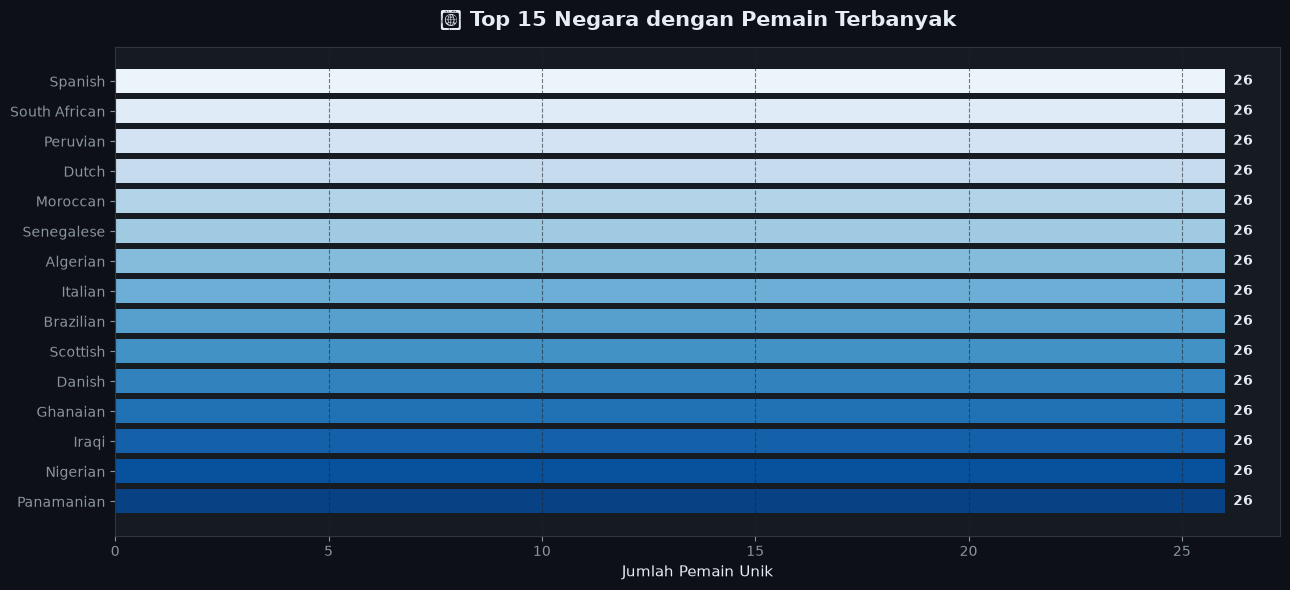

In [9]:
# ── Top Nationalities ────────────────────────────────────────────────────────
top_nations = player_info['nationality'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(top_nations.index[::-1], top_nations.values[::-1],
               color=sns.color_palette('Blues_r', 15), edgecolor='none')
for bar in bars:
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            str(int(bar.get_width())), va='center', fontsize=10, fontweight='bold', color='#e6edf3')
ax.set_title('🌍 Top 15 Negara dengan Pemain Terbanyak', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Jumlah Pemain Unik')
ax.grid(axis='x')
plt.tight_layout()
plt.show()

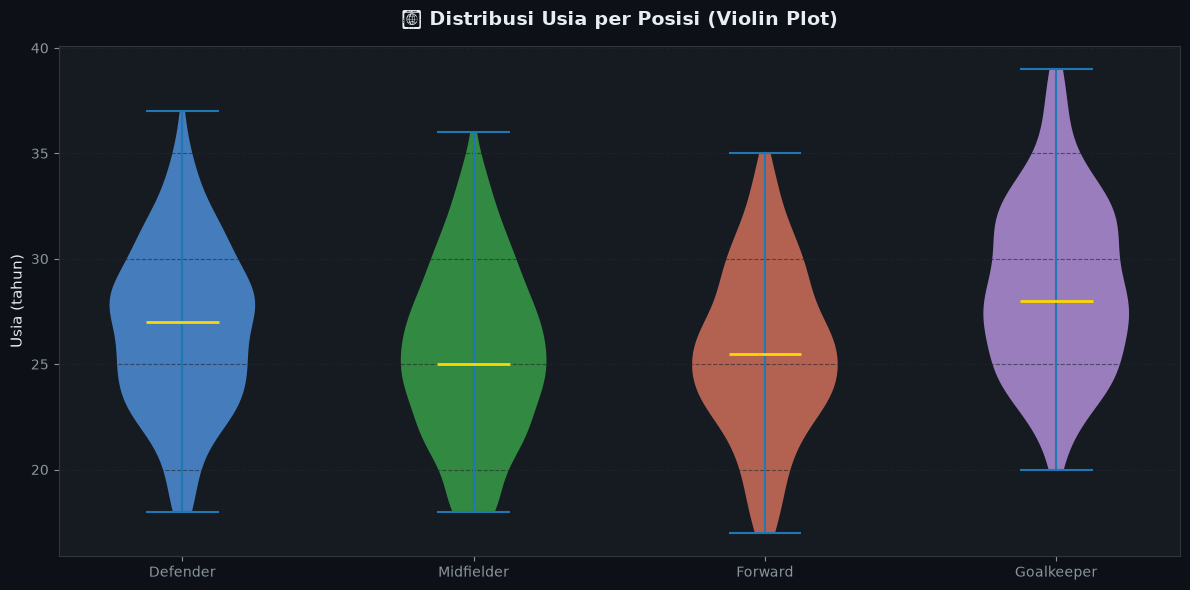

In [10]:
# ── Age Distribution by Position (Violin) ───────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
positions_list = player_info['position'].value_counts().index.tolist()
data_by_pos = [player_info[player_info['position'] == p]['age'].values for p in positions_list]

parts = ax.violinplot(data_by_pos, positions=range(len(positions_list)), showmedians=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(PALETTE_MAIN[i % len(PALETTE_MAIN)])
    pc.set_alpha(0.7)
parts['cmedians'].set_color(COLOR_GOLD)
parts['cmedians'].set_linewidth(2)
ax.set_xticks(range(len(positions_list)))
ax.set_xticklabels(positions_list)
ax.set_title('🎻 Distribusi Usia per Posisi (Violin Plot)', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Usia (tahun)')
ax.grid(axis='y')
plt.tight_layout()
plt.show()

---
## 5. Attacking Performance <a id='5'></a>

In [11]:
# ── Agregasi per pemain ──────────────────────────────────────────────────────
player_stats = df.groupby(['player_id', 'player_name', 'team', 'position', 'nationality']).agg(
    total_matches       = ('match_id', 'count'),
    total_minutes       = ('minutes_played', 'sum'),
    total_goals         = ('goals', 'sum'),
    total_assists       = ('assists', 'sum'),
    total_shots         = ('shots', 'sum'),
    total_shots_ot      = ('shots_on_target', 'sum'),
    total_xG            = ('expected_goals_xg', 'sum'),
    total_xA            = ('expected_assists_xa', 'sum'),
    total_key_passes    = ('key_passes', 'sum'),
    avg_pass_acc        = ('pass_accuracy', 'mean'),
    total_dribbles      = ('successful_dribbles', 'sum'),
    total_tackles       = ('tackles', 'sum'),
    total_interceptions = ('interceptions', 'sum'),
    avg_speed           = ('top_speed_kmh', 'mean'),
    avg_distance        = ('distance_covered_km', 'mean'),
    avg_stamina         = ('stamina_score', 'mean'),
    avg_rating          = ('player_rating', 'mean'),
    avg_perf_score      = ('performance_score', 'mean'),
    player_of_match     = ('player_of_match_awards', 'sum'),
    yellow_cards        = ('yellow_cards', 'sum'),
    red_cards           = ('red_cards', 'sum'),
).reset_index()

player_stats['conversion_rate'] = (
    player_stats['total_goals'] / player_stats['total_shots'].replace(0, np.nan)
).fillna(0)
player_stats['xG_diff'] = player_stats['total_goals'] - player_stats['total_xG']

print(f'📊 Agregasi selesai untuk {len(player_stats):,} pemain unik')
player_stats.head()

📊 Agregasi selesai untuk 1,248 pemain unik


,player_id,player_name,team,position,nationality,total_matches,total_minutes,total_goals,total_assists,total_shots,total_shots_ot,total_xG,total_xA,total_key_passes,avg_pass_acc,total_dribbles,total_tackles,total_interceptions,avg_speed,avg_distance,avg_stamina,avg_rating,avg_perf_score,player_of_match,yellow_cards,red_cards,conversion_rate,xG_diff
0,P00001,Kylian Griezmann,France,Goalkeeper,French,34,953,0,0,0,0,0.00,0.00,4,0.73,0,0,5,10.78,2.62,80.55,2.33,23.83,0,1,0,0.00,0.00
1,P00002,Antoine Tchouameni,France,Goalkeeper,French,34,830,0,0,0,0,0.00,0.00,6,0.73,0,0,3,8.46,2.35,80.19,1.96,20.32,0,7,0,0.00,0.00
2,P00003,Ousmane Hernandez,France,Goalkeeper,French,34,922,0,0,0,0,0.00,0.00,1,0.71,1,0,4,9.44,2.55,79.92,2.04,21.75,0,2,0,0.00,0.00
3,P00004,Kylian Camavinga,France,Defender,French,34,1299,0,0,8,1,0.06,0.01,9,0.81,0,41,31,19.09,4.15,81.89,3.47,35.86,0,3,0,0.00,-0.06
4,P00005,Antoine Kounde,France,Defender,French,34,1298,0,2,7,0,0.18,0.20,12,0.82,0,43,41,19.82,4.08,85.01,4.27,43.15,0,7,0,0.00,-0.18


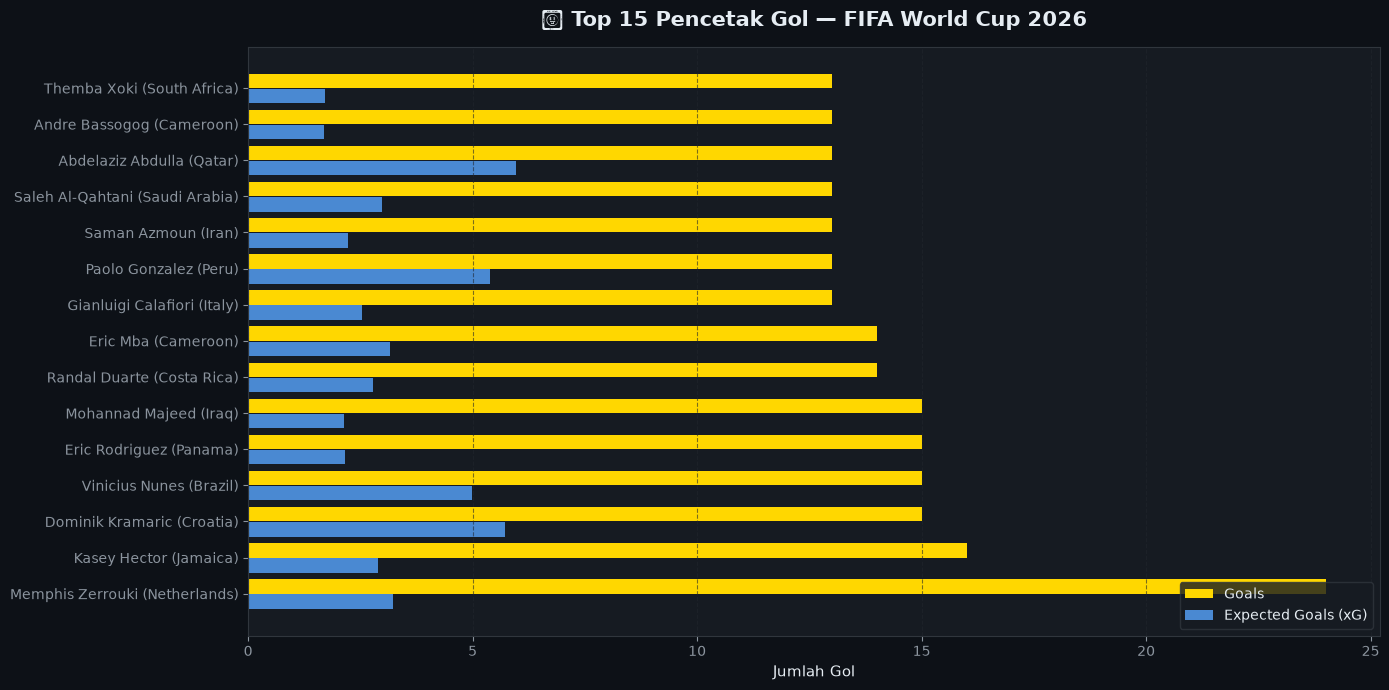

In [12]:
# ── Top Scorers ──────────────────────────────────────────────────────────────
top_scorers = player_stats.nlargest(15, 'total_goals')[
    ['player_name','team','position','total_goals','total_assists','total_shots','total_xG']
]

fig, ax = plt.subplots(figsize=(14, 7))
y_pos = np.arange(len(top_scorers))

ax.barh(y_pos, top_scorers['total_goals'], color=COLOR_GOLD, edgecolor='none', label='Goals', height=0.4)
ax.barh(y_pos - 0.42, top_scorers['total_xG'], color=COLOR_BLUE, edgecolor='none',
        label='Expected Goals (xG)', alpha=0.8, height=0.4)

ax.set_yticks(y_pos - 0.2)
ax.set_yticklabels([f"{r['player_name']} ({r['team']})" for _, r in top_scorers.iterrows()], fontsize=10)
ax.set_xlabel('Jumlah Gol')
ax.set_title('🥇 Top 15 Pencetak Gol — FIFA World Cup 2026', fontsize=15, fontweight='bold', pad=15)
ax.legend(loc='lower right')
ax.grid(axis='x')
plt.tight_layout()
plt.show()

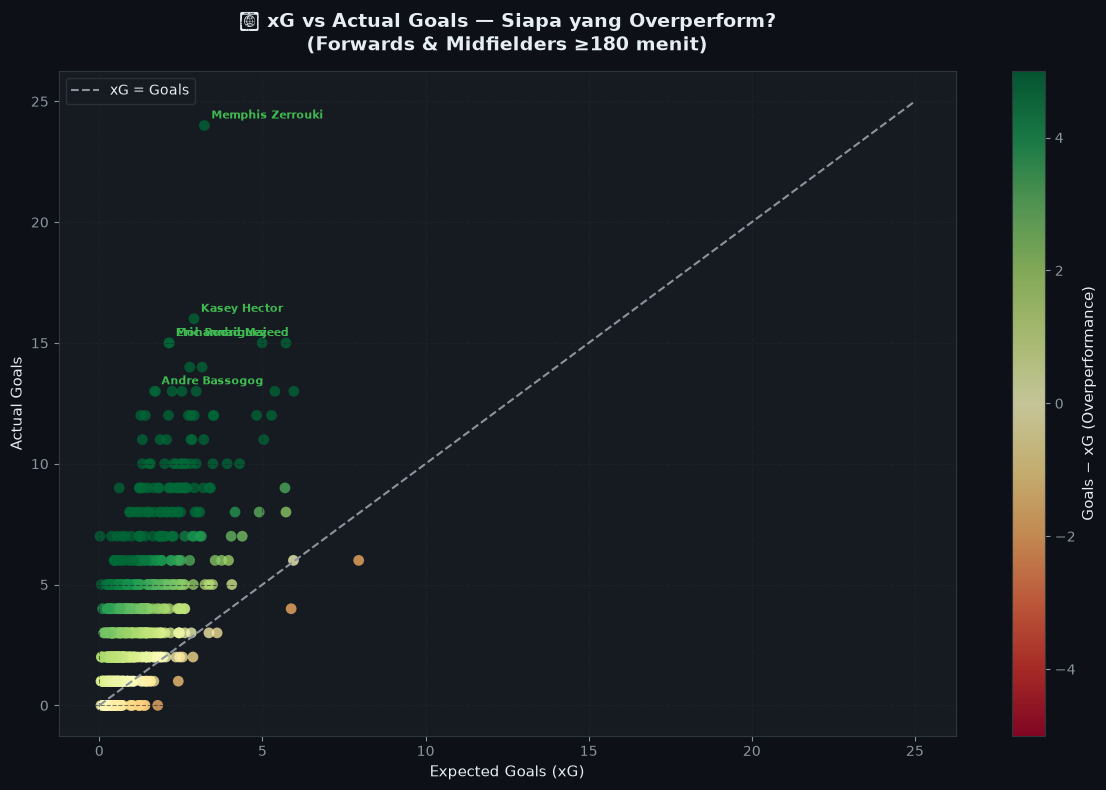

In [13]:
# ── xG vs Actual Goals Scatter ───────────────────────────────────────────────
atk = player_stats[(player_stats['position'].isin(['Forward','Midfielder'])) &
                   (player_stats['total_minutes'] >= 180)].copy()

fig, ax = plt.subplots(figsize=(12, 8))
sc = ax.scatter(atk['total_xG'], atk['total_goals'],
                c=atk['xG_diff'], cmap='RdYlGn', vmin=-5, vmax=5,
                s=60, alpha=0.75, edgecolors='none')

max_val = max(atk['total_xG'].max(), atk['total_goals'].max()) + 1
ax.plot([0, max_val], [0, max_val], color='#8b949e', linestyle='--', linewidth=1.5, label='xG = Goals')

top_over = atk.nlargest(5, 'xG_diff')
for _, row in top_over.iterrows():
    ax.annotate(row['player_name'], (row['total_xG'], row['total_goals']),
                xytext=(5, 5), textcoords='offset points', fontsize=8,
                color=COLOR_GREEN, fontweight='bold')

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Goals − xG (Overperformance)', color='#e6edf3')
ax.set_xlabel('Expected Goals (xG)')
ax.set_ylabel('Actual Goals')
ax.set_title('📈 xG vs Actual Goals — Siapa yang Overperform?\n(Forwards & Midfielders ≥180 menit)',
             fontweight='bold', pad=15)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

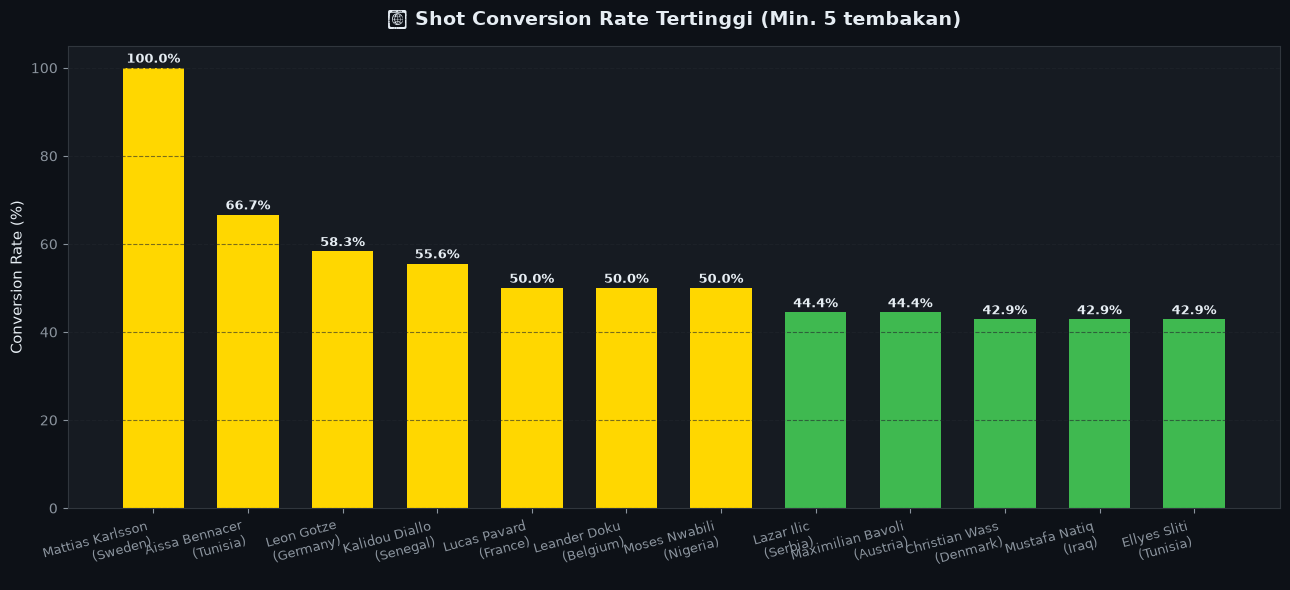

In [14]:
# ── Shot Conversion Rate ─────────────────────────────────────────────────────
conv_df = player_stats[(player_stats['total_shots'] >= 5) &
                       (player_stats['total_goals'] >= 1)].nlargest(12, 'conversion_rate')

fig, ax = plt.subplots(figsize=(13, 6))
colors_conv = [COLOR_GOLD if r >= 0.5 else COLOR_GREEN if r >= 0.3 else COLOR_BLUE
               for r in conv_df['conversion_rate']]
ax.bar(range(len(conv_df)), conv_df['conversion_rate'] * 100, color=colors_conv, edgecolor='none', width=0.65)
ax.set_xticks(range(len(conv_df)))
ax.set_xticklabels([f"{r['player_name']}\n({r['team']})" for _, r in conv_df.iterrows()],
                    fontsize=9, rotation=15, ha='right')
for i, v in enumerate(conv_df['conversion_rate'] * 100):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('🎯 Shot Conversion Rate Tertinggi (Min. 5 tembakan)', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Conversion Rate (%)')
ax.grid(axis='y')
plt.tight_layout()
plt.show()

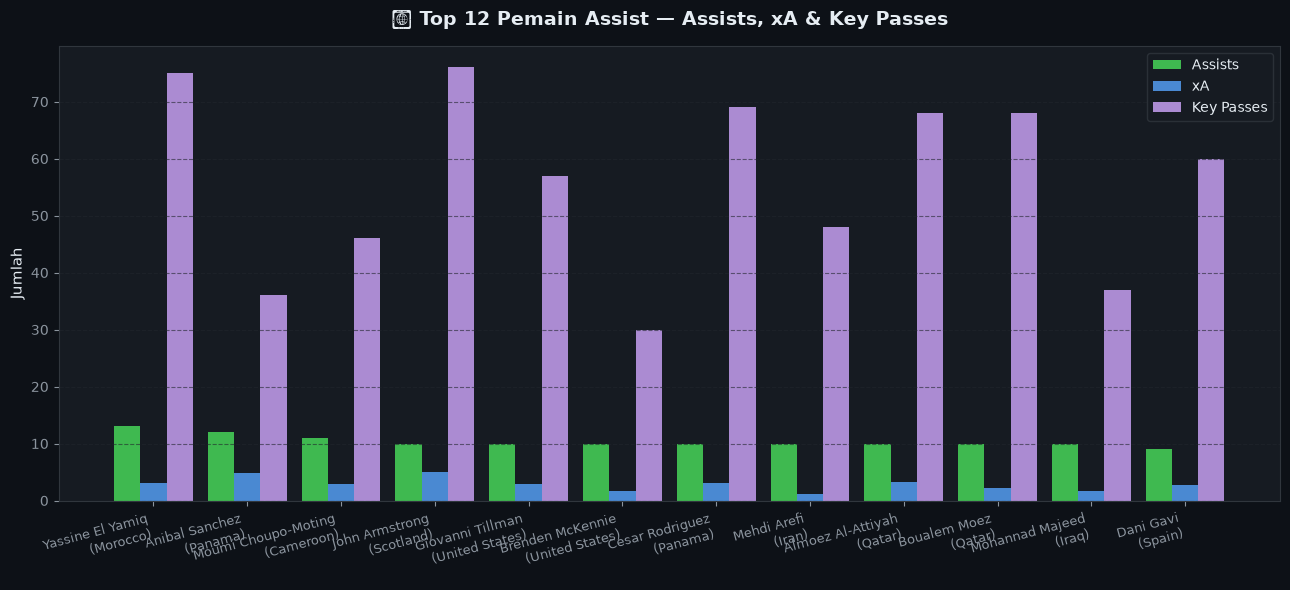

In [15]:
# ── Top Assistmen ────────────────────────────────────────────────────────────
top_ast = player_stats.nlargest(12, 'total_assists')[
    ['player_name','team','position','total_assists','total_key_passes','total_xA']
]

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(top_ast))
width = 0.28
ax.bar(x - width, top_ast['total_assists'],   width=width, color=COLOR_GREEN,  label='Assists',       edgecolor='none')
ax.bar(x,         top_ast['total_xA'],        width=width, color=COLOR_BLUE,   label='xA',            edgecolor='none', alpha=0.8)
ax.bar(x + width, top_ast['total_key_passes'],width=width, color=COLOR_PURPLE, label='Key Passes',    edgecolor='none', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f"{r['player_name']}\n({r['team']})" for _, r in top_ast.iterrows()],
                    fontsize=9, rotation=15, ha='right')
ax.set_title('🎁 Top 12 Pemain Assist — Assists, xA & Key Passes', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Jumlah')
ax.legend()
ax.grid(axis='y')
plt.tight_layout()
plt.show()

---
## 6. Passing & Creativity <a id='6'></a>

In [16]:
# ── Pass Accuracy by Position ────────────────────────────────────────────────
pass_by_pos = df.groupby('position')['pass_accuracy'].agg(['mean','median','std']).reset_index()
pass_by_pos.columns = ['Position', 'Mean Accuracy', 'Median Accuracy', 'Std Dev']
print('📊 Rata-rata Pass Accuracy per Posisi')
display(pass_by_pos.style.background_gradient(cmap='Greens', subset=['Mean Accuracy', 'Median Accuracy']))

📊 Rata-rata Pass Accuracy per Posisi


,Position,Mean Accuracy,Median Accuracy,Std Dev
0,Defender,0.820244,0.820000,0.060018
1,Forward,0.779776,0.780000,0.069752
2,Goalkeeper,0.720851,0.720000,0.079954
3,Midfielder,0.849505,0.850000,0.050005


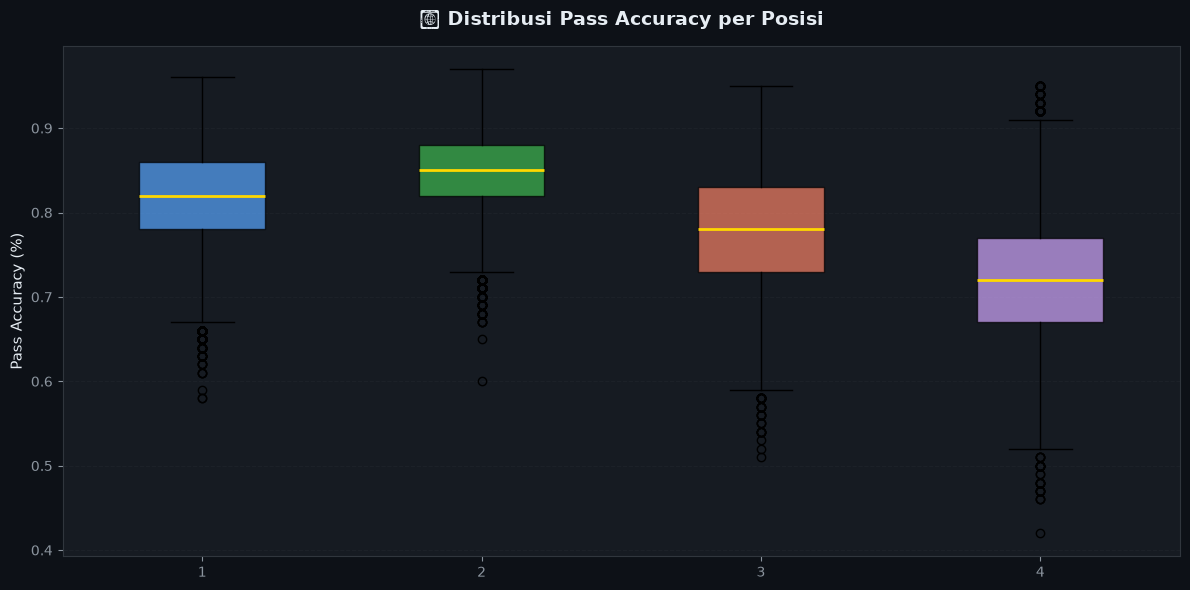

In [17]:
# ── Pass Accuracy Distribution per Position (Box Plot) ─────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
positions_order = df['position'].value_counts().index.tolist()
data_pass = [df[df['position'] == p]['pass_accuracy'].dropna().values for p in positions_order]

bp = ax.boxplot(data_pass, patch_artist=True, label=positions_order,
                medianprops={'color': COLOR_GOLD, 'linewidth': 2})
for patch, color in zip(bp['boxes'], PALETTE_MAIN):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('📬 Distribusi Pass Accuracy per Posisi', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Pass Accuracy (%)')
ax.grid(axis='y')
plt.tight_layout()
plt.show()

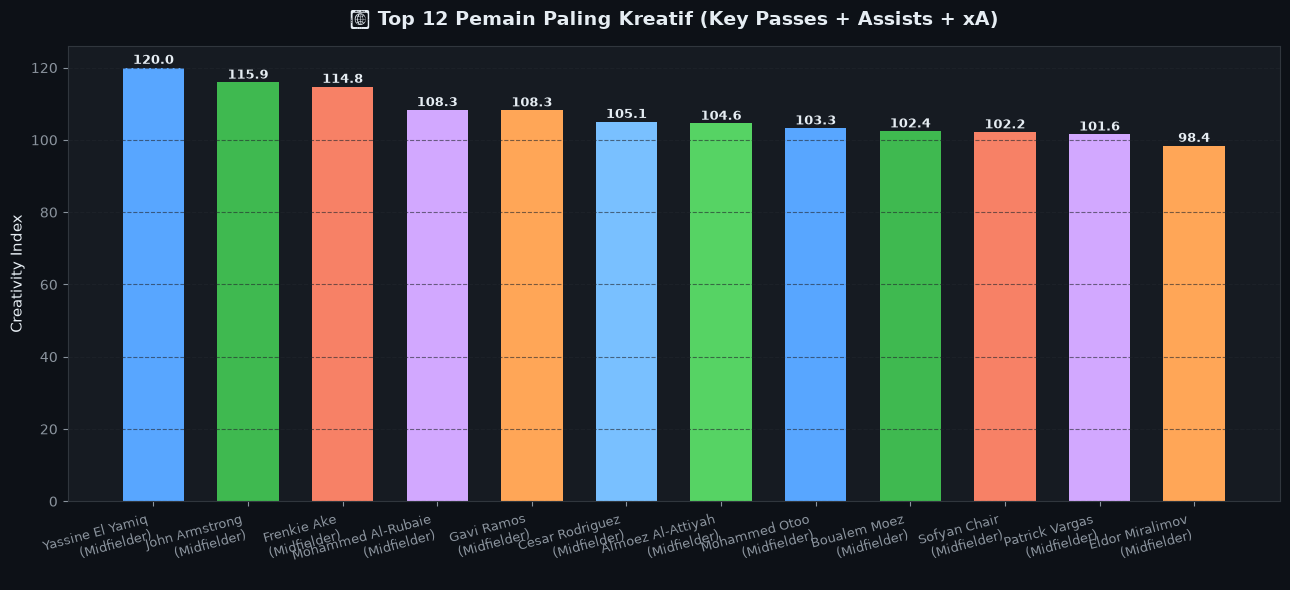

In [18]:
# ── Top Creative Players ─────────────────────────────────────────────────────
player_stats['creativity_index'] = (
    player_stats['total_key_passes'] * 1.0 +
    player_stats['total_assists']    * 3.0 +
    player_stats['total_xA']         * 2.0
)

top_creative = player_stats[player_stats['total_minutes'] >= 180].nlargest(12, 'creativity_index')

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(range(len(top_creative)), top_creative['creativity_index'],
              color=PALETTE_MAIN * 2, edgecolor='none', width=0.65)
ax.set_xticks(range(len(top_creative)))
ax.set_xticklabels([f"{r['player_name']}\n({r['position']})" for _, r in top_creative.iterrows()],
                    fontsize=9, rotation=15, ha='right')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('💡 Top 12 Pemain Paling Kreatif (Key Passes + Assists + xA)', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Creativity Index')
ax.grid(axis='y')
plt.tight_layout()
plt.show()

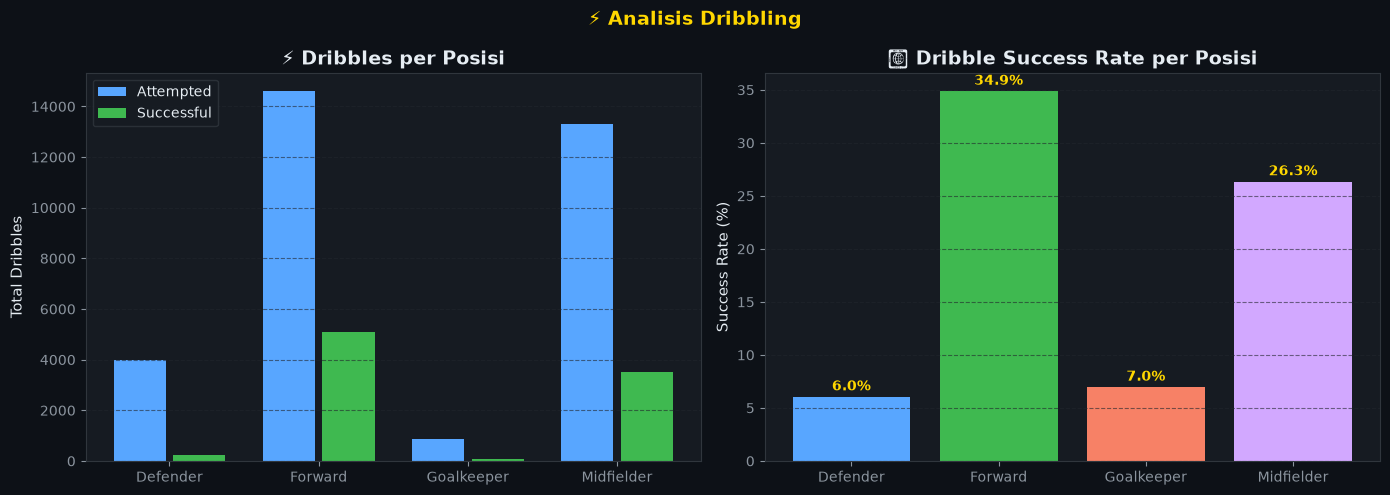

In [19]:
# ── Dribbling Analysis ───────────────────────────────────────────────────────
dribble_df = df.groupby('position').agg(
    total_attempted = ('dribbles_attempted', 'sum'),
    total_success   = ('successful_dribbles', 'sum')
).reset_index()
dribble_df['success_rate'] = dribble_df['total_success'] / dribble_df['total_attempted'] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(dribble_df))

axes[0].bar(x - 0.2, dribble_df['total_attempted'], width=0.35, color=COLOR_BLUE,  label='Attempted',  edgecolor='none')
axes[0].bar(x + 0.2, dribble_df['total_success'],   width=0.35, color=COLOR_GREEN, label='Successful', edgecolor='none')
axes[0].set_xticks(x)
axes[0].set_xticklabels(dribble_df['position'])
axes[0].set_title('⚡ Dribbles per Posisi', fontweight='bold')
axes[0].set_ylabel('Total Dribbles')
axes[0].legend()
axes[0].grid(axis='y')

axes[1].bar(dribble_df['position'], dribble_df['success_rate'],
            color=PALETTE_MAIN[:len(dribble_df)], edgecolor='none')
for i, rate in enumerate(dribble_df['success_rate']):
    axes[1].text(i, rate + 0.3, f'{rate:.1f}%', ha='center', va='bottom', fontweight='bold', color=COLOR_GOLD)
axes[1].set_title('🎯 Dribble Success Rate per Posisi', fontweight='bold')
axes[1].set_ylabel('Success Rate (%)')
axes[1].grid(axis='y')

plt.suptitle('⚡ Analisis Dribbling', fontsize=14, fontweight='bold', color=COLOR_GOLD)
plt.tight_layout()
plt.show()

---
## 7. Defensive Performance <a id='7'></a>

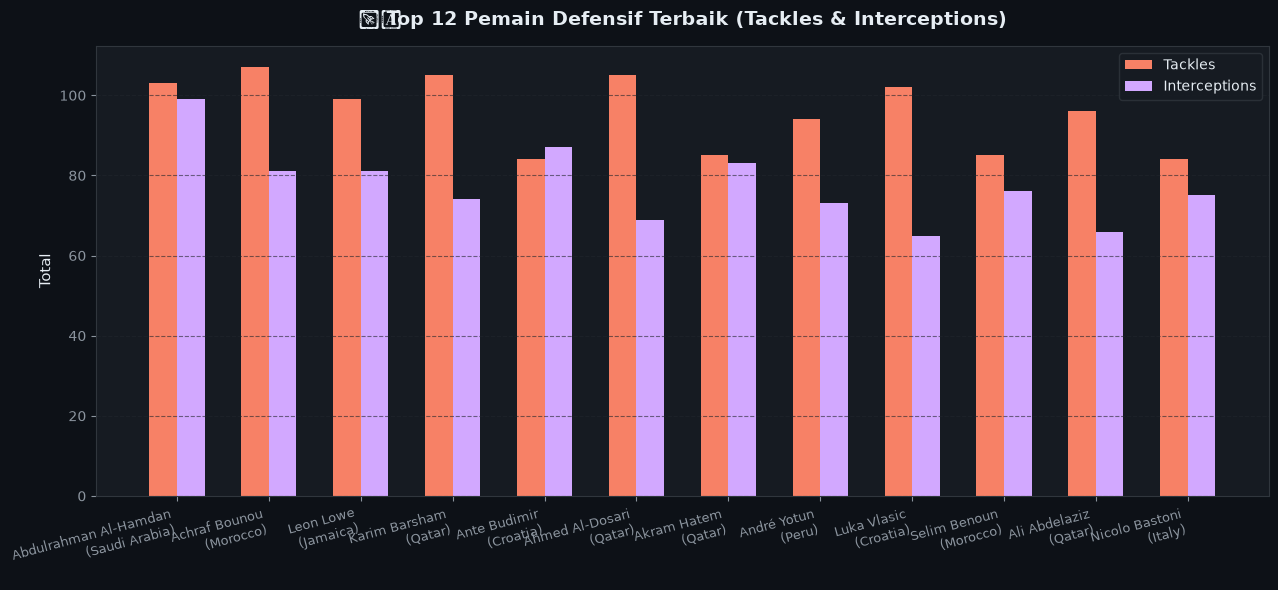

In [20]:
# ── Top Defenders ────────────────────────────────────────────────────────────
player_stats['defensive_index'] = (
    player_stats['total_tackles'] * 2.0 +
    player_stats['total_interceptions'] * 2.5
)

top_defenders = player_stats[
    player_stats['position'].isin(['Defender', 'Midfielder']) &
    (player_stats['total_minutes'] >= 180)
].nlargest(12, 'defensive_index')

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(top_defenders))
width = 0.3
ax.bar(x - width/2, top_defenders['total_tackles'],       width=width, color=COLOR_RED,    label='Tackles',       edgecolor='none')
ax.bar(x + width/2, top_defenders['total_interceptions'], width=width, color=COLOR_PURPLE, label='Interceptions', edgecolor='none')
ax.set_xticks(x)
ax.set_xticklabels([f"{r['player_name']}\n({r['team']})" for _, r in top_defenders.iterrows()],
                    fontsize=9, rotation=15, ha='right')
ax.set_title('🛡️ Top 12 Pemain Defensif Terbaik (Tackles & Interceptions)', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Total')
ax.legend()
ax.grid(axis='y')
plt.tight_layout()
plt.show()

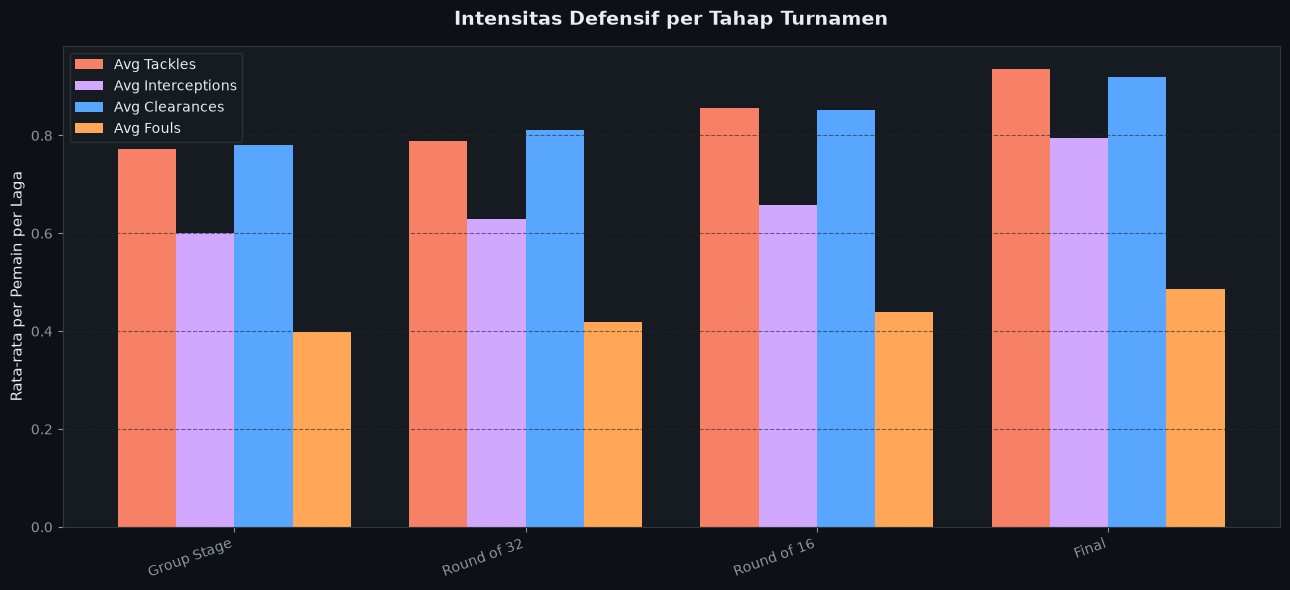

In [21]:
# ── Defensive Stats per Stage ────────────────────────────────────────────────
STAGE_ORDER = ['Group Stage', 'Round of 32', 'Round of 16', 'Quarter-Final', 'Semi-Final', 'Third Place', 'Final']

def_by_stage = df.groupby('tournament_stage').agg(
    avg_tackles       = ('tackles', 'mean'),
    avg_interceptions = ('interceptions', 'mean'),
    avg_clearances    = ('clearances', 'mean'),
    avg_fouls         = ('fouls_committed', 'mean'),
).reset_index()
def_by_stage['stage_order'] = def_by_stage['tournament_stage'].map({s: i for i, s in enumerate(STAGE_ORDER)})
def_by_stage = def_by_stage.sort_values('stage_order').dropna(subset=['stage_order'])

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(def_by_stage))
w = 0.2
ax.bar(x - 1.5*w, def_by_stage['avg_tackles'],       width=w, color=COLOR_RED,    label='Avg Tackles',       edgecolor='none')
ax.bar(x - 0.5*w, def_by_stage['avg_interceptions'], width=w, color=COLOR_PURPLE, label='Avg Interceptions', edgecolor='none')
ax.bar(x + 0.5*w, def_by_stage['avg_clearances'],    width=w, color=COLOR_BLUE,   label='Avg Clearances',    edgecolor='none')
ax.bar(x + 1.5*w, def_by_stage['avg_fouls'],         width=w, color='#ffa657',    label='Avg Fouls',         edgecolor='none')
ax.set_xticks(x)
ax.set_xticklabels(def_by_stage['tournament_stage'], rotation=20, ha='right')
ax.set_title('Intensitas Defensif per Tahap Turnamen', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Rata-rata per Pemain per Laga')
ax.legend()
ax.grid(axis='y')
plt.tight_layout()
plt.show()

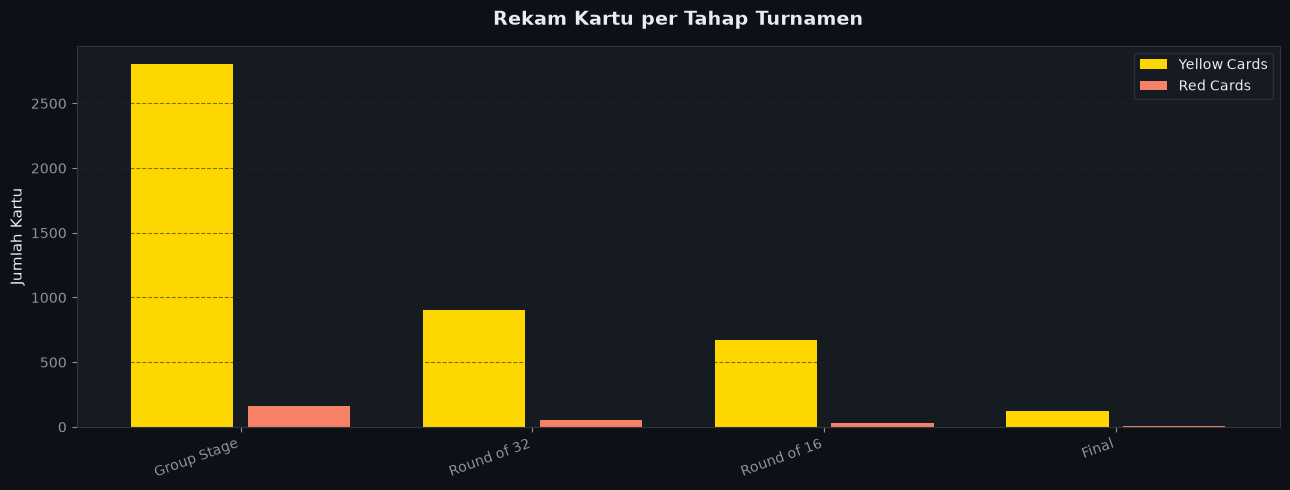

In [22]:
# ── Disciplinary Record (Cards) ─────────────────────────────────────────────
STAGE_ORDER = ['Group Stage', 'Round of 32', 'Round of 16', 'Quarter-Final', 'Semi-Final', 'Third Place', 'Final']
cards_by_stage = df.groupby('tournament_stage').agg(
    yellow_cards = ('yellow_cards', 'sum'),
    red_cards    = ('red_cards', 'sum')
).reset_index()
cards_by_stage['stage_order'] = cards_by_stage['tournament_stage'].map({s: i for i, s in enumerate(STAGE_ORDER)})
cards_by_stage = cards_by_stage.sort_values('stage_order').dropna(subset=['stage_order'])

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(cards_by_stage))
ax.bar(x - 0.2, cards_by_stage['yellow_cards'], width=0.35, color=COLOR_GOLD, label='Yellow Cards', edgecolor='none')
ax.bar(x + 0.2, cards_by_stage['red_cards'],    width=0.35, color=COLOR_RED,  label='Red Cards',    edgecolor='none')
ax.set_xticks(x)
ax.set_xticklabels(cards_by_stage['tournament_stage'], rotation=20, ha='right')
ax.set_title('Rekam Kartu per Tahap Turnamen', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Jumlah Kartu')
ax.legend()
ax.grid(axis='y')
plt.tight_layout()
plt.show()

---
## 8. Physical & Stamina Performance <a id='8'></a>

In [23]:
# ── Physical Stats per Position ─────────────────────────────────────────────
phys_by_pos = df.groupby('position').agg(
    avg_distance = ('distance_covered_km', 'mean'),
    avg_sprint   = ('sprint_distance_km', 'mean'),
    avg_speed    = ('top_speed_kmh', 'mean'),
    avg_stamina  = ('stamina_score', 'mean'),
).reset_index()

print('🏃 Rata-rata Fisik per Posisi')
display(phys_by_pos.style.background_gradient(
    cmap='Greens', subset=['avg_distance','avg_sprint','avg_speed','avg_stamina']))

🏃 Rata-rata Fisik per Posisi


,position,avg_distance,avg_sprint,avg_speed,avg_stamina
0,Defender,3.993116,0.463116,19.749418,82.170847
1,Forward,4.124524,0.480270,19.851714,82.374381
2,Goalkeeper,2.410810,0.276794,9.675905,78.844429
3,Midfielder,4.498935,0.517702,19.862970,82.364339


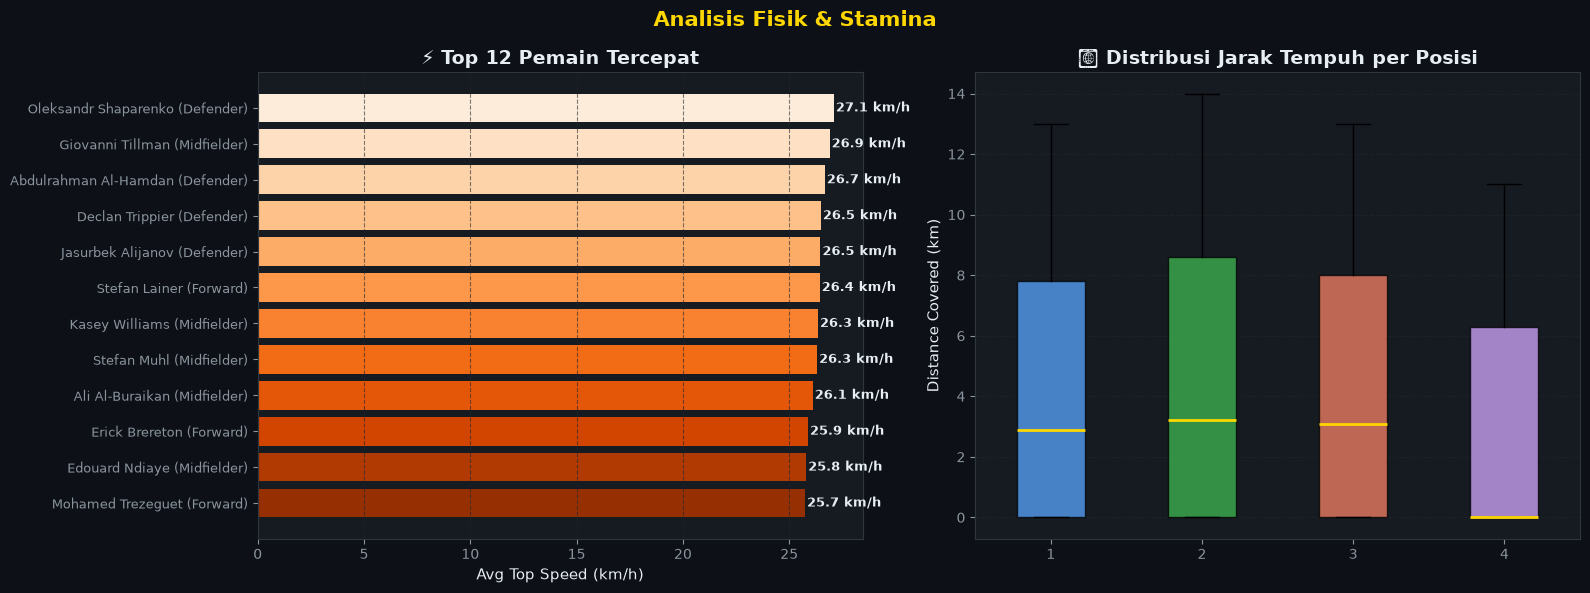

In [24]:
# ── Top Speed Players & Distance per Position ────────────────────────────────
top_speed_players = player_stats[player_stats['total_minutes'] >= 180].nlargest(12, 'avg_speed')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top speed players
ax = axes[0]
bars = ax.barh(range(len(top_speed_players)), top_speed_players['avg_speed'].values[::-1],
               color=sns.color_palette('Oranges_r', 12), edgecolor='none')
ax.set_yticks(range(len(top_speed_players)))
ax.set_yticklabels(
    [f"{r['player_name']} ({r['position']})" for _, r in top_speed_players[::-1].iterrows()], fontsize=9)
for bar in bars:
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f} km/h', va='center', fontsize=9, fontweight='bold')
ax.set_title('⚡ Top 12 Pemain Tercepat', fontweight='bold')
ax.set_xlabel('Avg Top Speed (km/h)')
ax.grid(axis='x')

# Distance by position (box plot)
ax = axes[1]
positions_phys = df['position'].value_counts().index.tolist()
data_dist = [df[df['position'] == p]['distance_covered_km'].dropna().values for p in positions_phys]
bp = ax.boxplot(data_dist, patch_artist=True, label=positions_phys,
                medianprops={'color': COLOR_GOLD, 'linewidth': 2})
for patch, color in zip(bp['boxes'], PALETTE_MAIN):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax.set_title('🏃 Distribusi Jarak Tempuh per Posisi', fontweight='bold')
ax.set_ylabel('Distance Covered (km)')
ax.grid(axis='y')

plt.suptitle('Analisis Fisik & Stamina', fontsize=15, fontweight='bold', color=COLOR_GOLD)
plt.tight_layout()
plt.show()

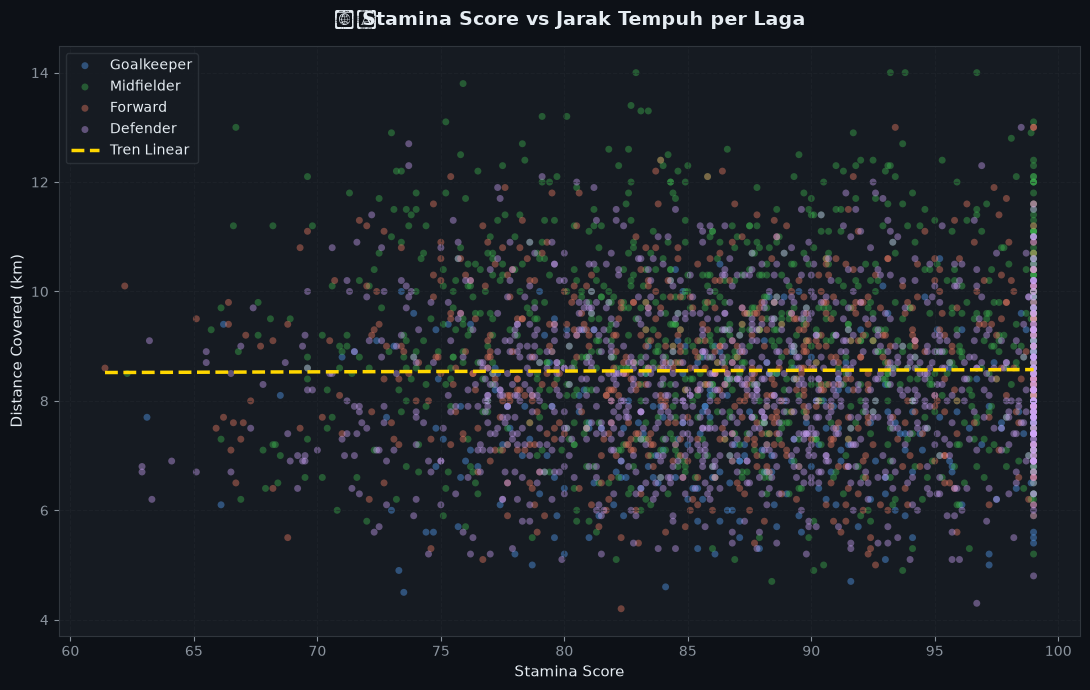

In [25]:
# ── Stamina Score vs Distance Covered Scatter ────────────────────────────────
sample_phys = df[df['minutes_played'] >= 60].sample(min(3000, len(df)), random_state=42)

fig, ax = plt.subplots(figsize=(11, 7))
for pos, color in zip(df['position'].unique(), PALETTE_MAIN):
    subset = sample_phys[sample_phys['position'] == pos]
    ax.scatter(subset['stamina_score'], subset['distance_covered_km'],
               alpha=0.4, s=25, label=pos, color=color, edgecolors='none')

# Trend line
valid = sample_phys[['stamina_score','distance_covered_km']].dropna()
z = np.polyfit(valid['stamina_score'], valid['distance_covered_km'], 1)
p = np.poly1d(z)
x_line = np.linspace(valid['stamina_score'].min(), valid['stamina_score'].max(), 100)
ax.plot(x_line, p(x_line), color=COLOR_GOLD, linewidth=2.5, linestyle='--', label='Tren Linear')

ax.set_title('🏋️ Stamina Score vs Jarak Tempuh per Laga', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Stamina Score')
ax.set_ylabel('Distance Covered (km)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

---
## 9. Overall Player Ratings & Performance Scores <a id='9'></a>

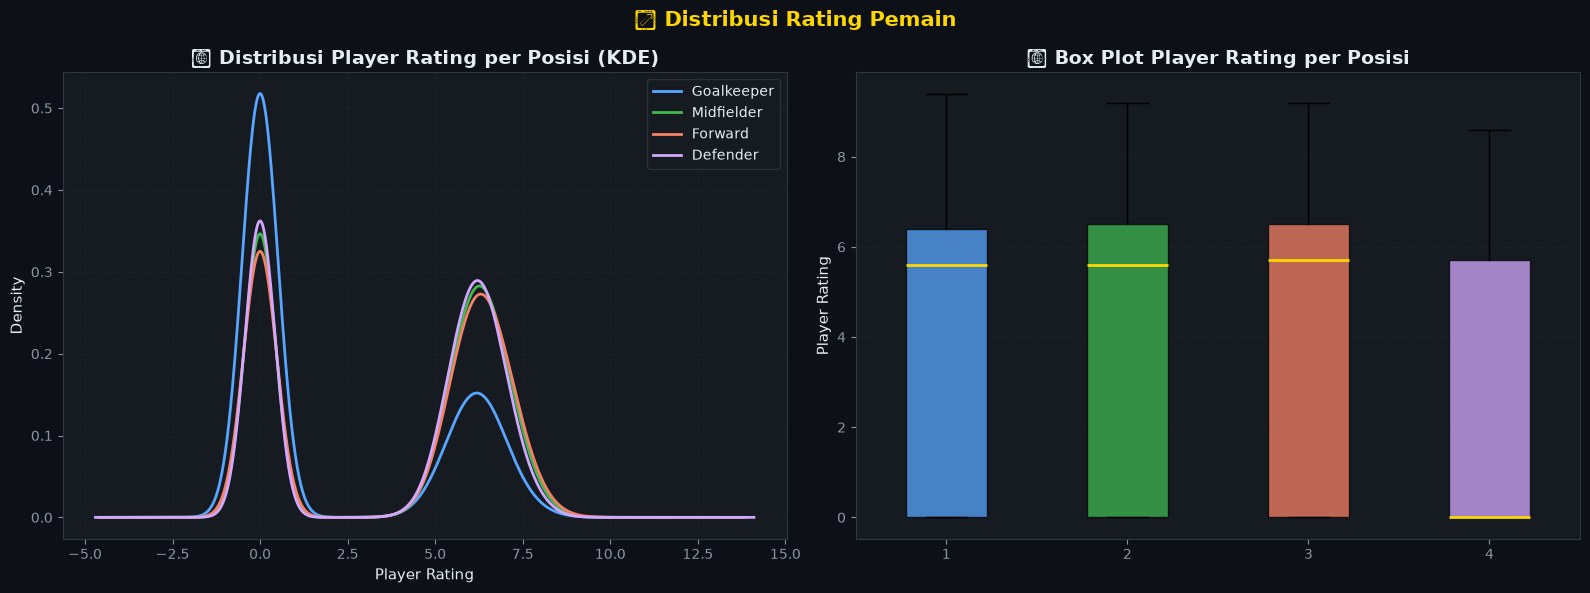

In [26]:
# ── Rating Distribution per Position ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# KDE plot
ax = axes[0]
for pos, color in zip(df['position'].unique(), PALETTE_MAIN):
    subset = df[df['position'] == pos]['player_rating'].dropna()
    subset.plot.kde(ax=ax, label=pos, color=color, linewidth=2)
ax.set_title('📊 Distribusi Player Rating per Posisi (KDE)', fontweight='bold')
ax.set_xlabel('Player Rating')
ax.set_ylabel('Density')
ax.legend()
ax.grid()

# Box Plot
ax = axes[1]
pos_list_rating = df['position'].value_counts().index.tolist()
data_rating = [df[df['position'] == p]['player_rating'].dropna().values for p in pos_list_rating]
bp = ax.boxplot(data_rating, patch_artist=True, label=pos_list_rating,
                medianprops={'color': COLOR_GOLD, 'linewidth': 2})
for patch, color in zip(bp['boxes'], PALETTE_MAIN):
    patch.set_facecolor(color); patch.set_alpha(0.75)
ax.set_title('📦 Box Plot Player Rating per Posisi', fontweight='bold')
ax.set_ylabel('Player Rating')
ax.grid(axis='y')

plt.suptitle('⭐ Distribusi Rating Pemain', fontsize=15, fontweight='bold', color=COLOR_GOLD)
plt.tight_layout()
plt.show()

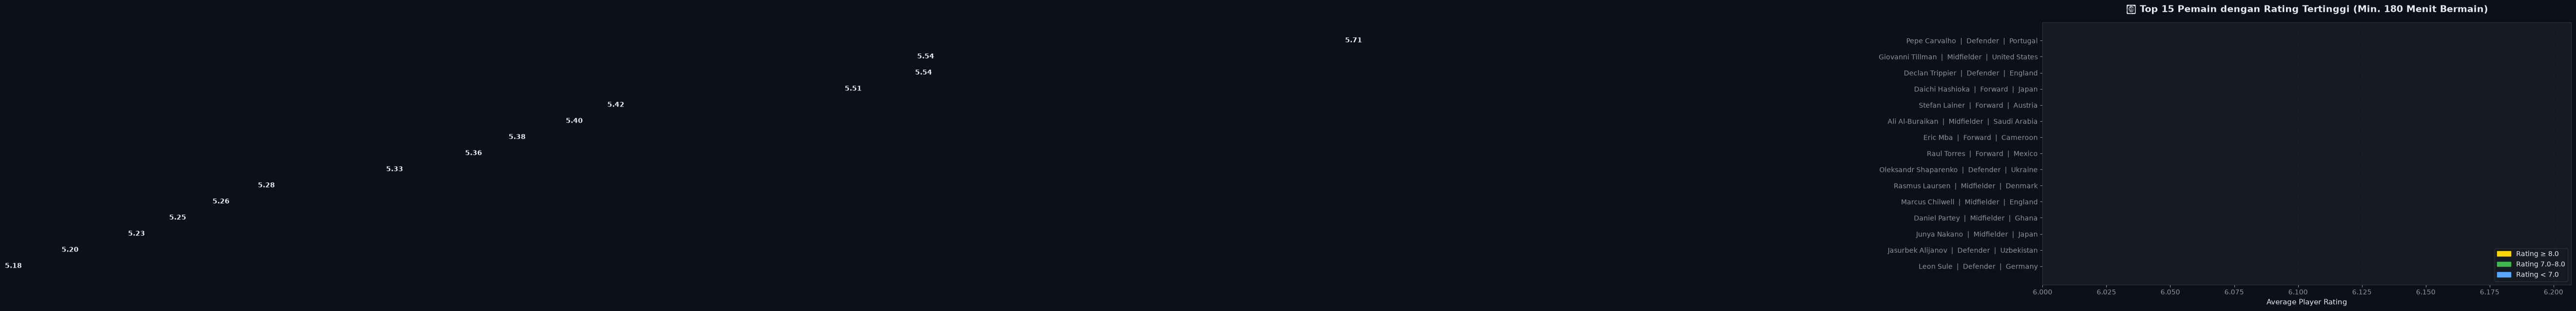

In [27]:
# ── Top Rated Players (Min 180 menit) ───────────────────────────────────────
top_rated = player_stats[player_stats['total_minutes'] >= 180].nlargest(15, 'avg_rating')

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(range(len(top_rated)), top_rated['avg_rating'].values[::-1],
               color=[COLOR_GOLD if r >= 8 else COLOR_GREEN if r >= 7 else COLOR_BLUE
                      for r in top_rated['avg_rating'].values[::-1]], edgecolor='none')
ax.set_yticks(range(len(top_rated)))
ax.set_yticklabels([f"{r['player_name']}  |  {r['position']}  |  {r['team']}"
                    for _, r in top_rated[::-1].iterrows()], fontsize=10)
for bar in bars:
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.2f}', va='center', fontsize=10, fontweight='bold')
ax.set_xlim(6, top_rated['avg_rating'].max() + 0.5)
ax.set_title('🏆 Top 15 Pemain dengan Rating Tertinggi (Min. 180 Menit Bermain)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Average Player Rating')
ax.grid(axis='x')
gold_p  = mpatches.Patch(color=COLOR_GOLD,  label='Rating ≥ 8.0')
green_p = mpatches.Patch(color=COLOR_GREEN, label='Rating 7.0–8.0')
blue_p  = mpatches.Patch(color=COLOR_BLUE,  label='Rating < 7.0')
ax.legend(handles=[gold_p, green_p, blue_p], loc='lower right')
plt.tight_layout()
plt.show()

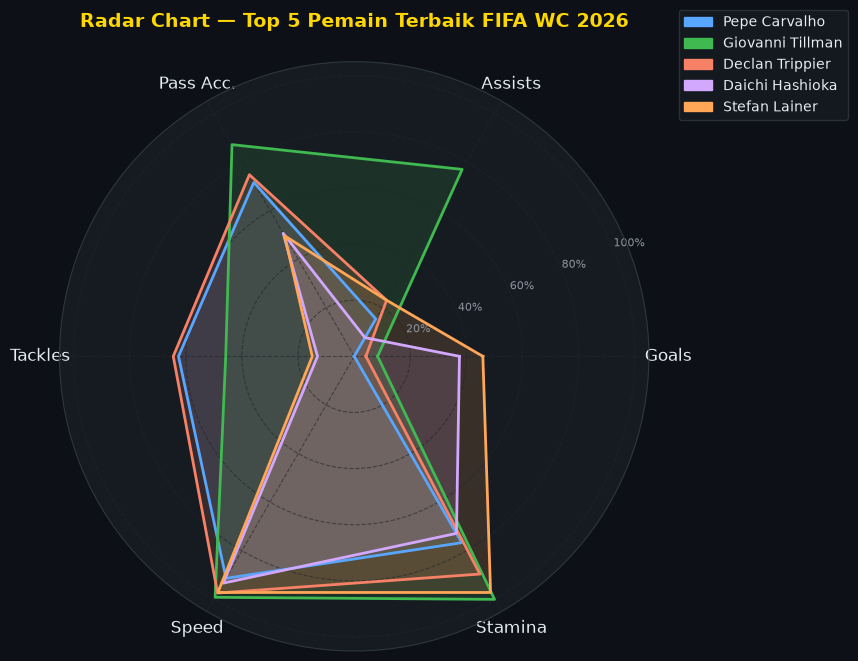

In [28]:
# ── Radar Chart — Top 5 Pemain Terbaik ──────────────────────────────────────
top5 = player_stats[player_stats['total_minutes'] >= 180].nlargest(5, 'avg_rating')
radar_cols_raw = ['total_goals', 'total_assists', 'avg_pass_acc', 'total_tackles', 'avg_speed', 'avg_stamina']
radar_labels   = ['Goals', 'Assists', 'Pass Acc.', 'Tackles', 'Speed', 'Stamina']

radar_data = top5[radar_cols_raw].copy()
for col in radar_cols_raw:
    col_min = player_stats[col].min()
    col_max = player_stats[col].max()
    radar_data[col] = (radar_data[col] - col_min) / (col_max - col_min + 1e-9)

angles = np.linspace(0, 2 * np.pi, len(radar_labels), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={'polar': True})
ax.set_facecolor('#161b22')
fig.patch.set_facecolor('#0d1117')

for i, (_, row) in enumerate(top5.iterrows()):
    values = radar_data.iloc[i].tolist() + [radar_data.iloc[i].tolist()[0]]
    ax.plot(angles, values, color=PALETTE_MAIN[i], linewidth=2)
    ax.fill(angles, values, color=PALETTE_MAIN[i], alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=12, color='#e6edf3')
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['20%','40%','60%','80%','100%'], fontsize=8, color='#8b949e')
ax.spines['polar'].set_color('#30363d')
ax.grid(color='#21262d', linewidth=0.8)

legend_patches = [mpatches.Patch(color=PALETTE_MAIN[i], label=top5.iloc[i]['player_name'])
                  for i in range(len(top5))]
ax.legend(handles=legend_patches, loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10)
ax.set_title('Radar Chart — Top 5 Pemain Terbaik FIFA WC 2026',
             fontsize=14, fontweight='bold', color=COLOR_GOLD, pad=25)
plt.tight_layout()
plt.show()

---
## 10. Team Analysis <a id='10'></a>

In [29]:
# ── Team Aggregation ─────────────────────────────────────────────────────────
match_results = df.groupby(['match_id', 'team', 'tournament_stage', 'match_result']).agg(
    goals_scored   = ('goals_team', 'first'),
    goals_conceded = ('goals_opponent', 'first'),
    avg_rating     = ('player_rating', 'mean'),
).reset_index()

team_agg = match_results.groupby('team').agg(
    total_matches = ('match_id', 'count'),
    wins          = ('match_result', lambda x: (x == 'W').sum()),
    draws         = ('match_result', lambda x: (x == 'D').sum()),
    losses        = ('match_result', lambda x: (x == 'L').sum()),
    total_goals_f = ('goals_scored', 'sum'),
    total_goals_a = ('goals_conceded', 'sum'),
    avg_rating    = ('avg_rating', 'mean'),
).reset_index()

team_agg['win_rate']  = team_agg['wins'] / team_agg['total_matches'] * 100
team_agg['goal_diff'] = team_agg['total_goals_f'] - team_agg['total_goals_a']
team_agg['goals_pg']  = team_agg['total_goals_f'] / team_agg['total_matches']

top_teams_wr = team_agg.nlargest(15, 'win_rate')
print('🏆 Top 15 Tim Berdasarkan Win Rate')
display(top_teams_wr[['team','total_matches','wins','draws','losses',
                        'total_goals_f','total_goals_a','goal_diff','win_rate']]
        .style.background_gradient(cmap='Greens', subset=['win_rate','goal_diff']))

🏆 Top 15 Tim Berdasarkan Win Rate


,team,total_matches,wins,draws,losses,total_goals_f,total_goals_a,goal_diff,win_rate
27,Nigeria,40,23,10,7,68,42,26,57.500000
9,Colombia,46,24,4,18,66,61,5,52.173913
5,Brazil,45,22,11,12,73,53,20,48.888889
31,Portugal,43,21,9,13,63,57,6,48.837209
4,Belgium,51,24,11,16,79,70,9,47.058824
0,Algeria,41,19,7,15,60,51,9,46.341463
22,Jamaica,59,27,9,23,88,80,8,45.762712
15,England,44,20,12,12,61,53,8,45.454545
23,Japan,36,16,7,13,50,40,10,44.444444
25,Morocco,55,24,16,15,78,54,24,43.636364


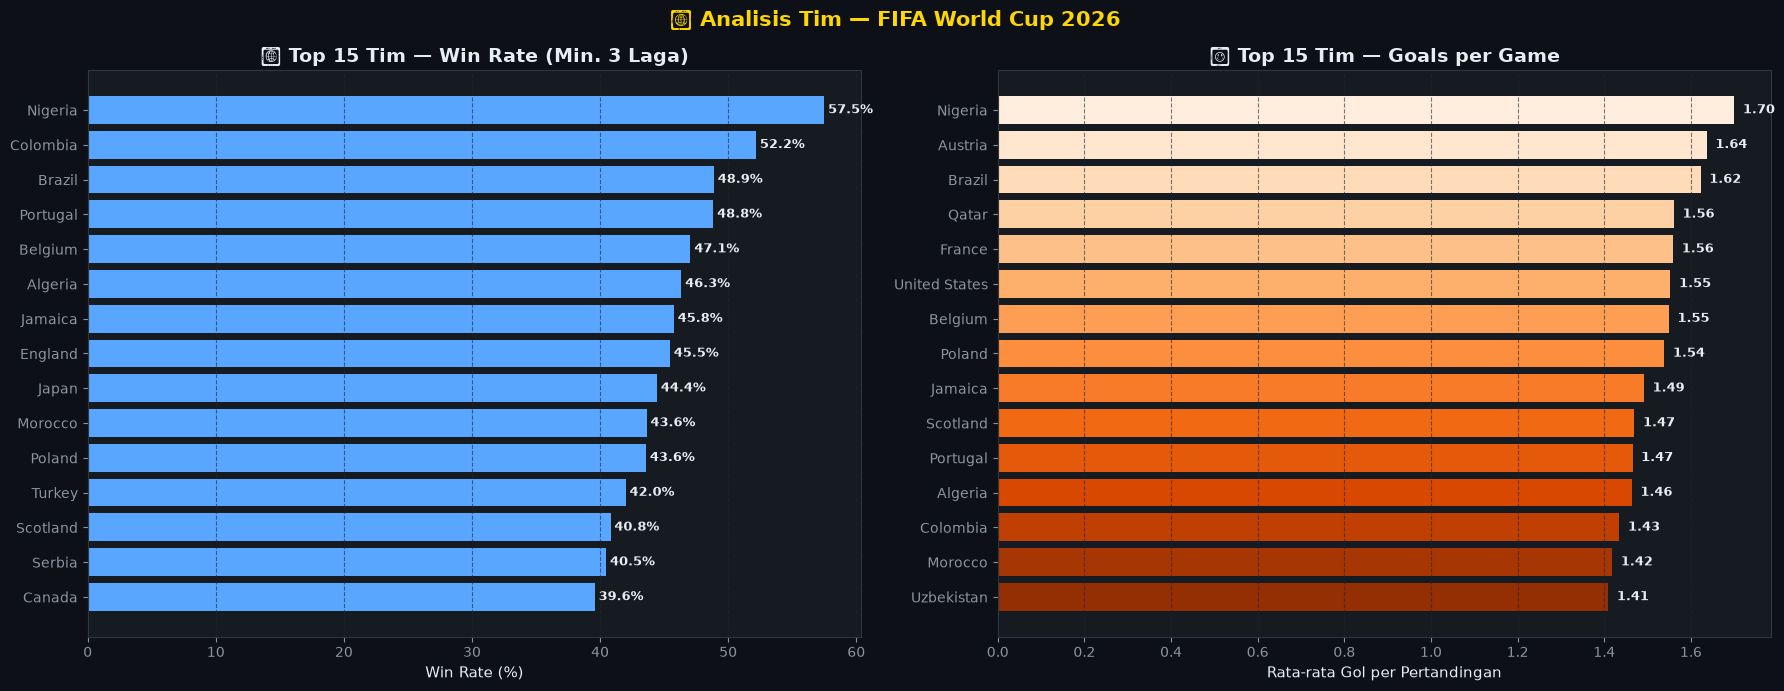

In [30]:
# ── Top Teams Win Rate & Goals per Game ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Win rate
top15_wr = team_agg[team_agg['total_matches'] >= 3].nlargest(15, 'win_rate')
ax = axes[0]
bars = ax.barh(range(len(top15_wr)), top15_wr['win_rate'].values[::-1],
               color=[COLOR_GOLD if w >= 80 else COLOR_GREEN if w >= 60 else COLOR_BLUE
                      for w in top15_wr['win_rate'].values[::-1]], edgecolor='none')
ax.set_yticks(range(len(top15_wr)))
ax.set_yticklabels(top15_wr['team'].values[::-1], fontsize=10)
for bar in bars:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f}%', va='center', fontsize=9, fontweight='bold')
ax.set_title('🏆 Top 15 Tim — Win Rate (Min. 3 Laga)', fontweight='bold')
ax.set_xlabel('Win Rate (%)')
ax.grid(axis='x')

# Goals per game
top15_gp = team_agg[team_agg['total_matches'] >= 3].nlargest(15, 'goals_pg')
ax = axes[1]
bars = ax.barh(range(len(top15_gp)), top15_gp['goals_pg'].values[::-1],
               color=sns.color_palette('Oranges_r', 15), edgecolor='none')
ax.set_yticks(range(len(top15_gp)))
ax.set_yticklabels(top15_gp['team'].values[::-1], fontsize=10)
for bar in bars:
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.2f}', va='center', fontsize=9, fontweight='bold')
ax.set_title('⚽ Top 15 Tim — Goals per Game', fontweight='bold')
ax.set_xlabel('Rata-rata Gol per Pertandingan')
ax.grid(axis='x')

plt.suptitle('🌍 Analisis Tim — FIFA World Cup 2026', fontsize=15, fontweight='bold', color=COLOR_GOLD)
plt.tight_layout()
plt.show()

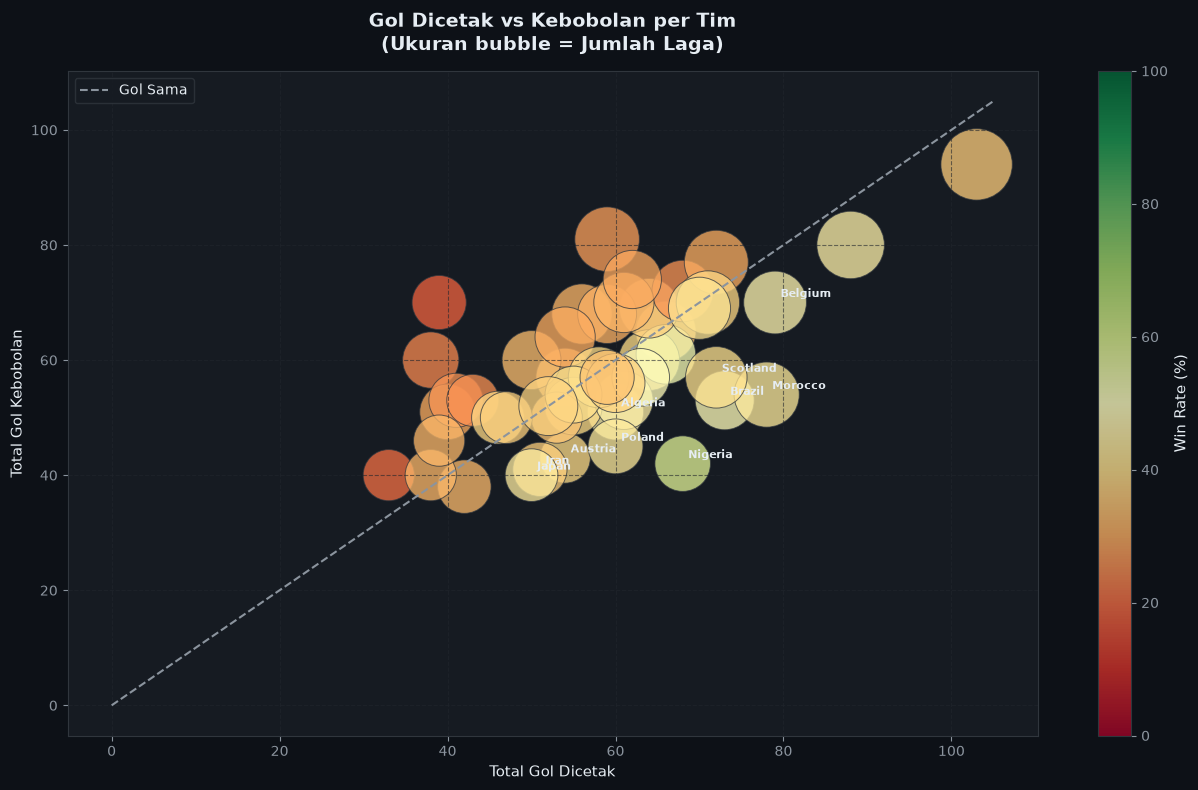

In [31]:
# ── Goals Scored vs Goals Conceded (Bubble Chart) ────────────────────────────
team_plot = team_agg[team_agg['total_matches'] >= 3].copy()

fig, ax = plt.subplots(figsize=(13, 8))
scatter = ax.scatter(
    team_plot['total_goals_f'], team_plot['total_goals_a'],
    s=team_plot['total_matches'] * 40,
    c=team_plot['win_rate'], cmap='RdYlGn', vmin=0, vmax=100,
    alpha=0.75, edgecolors='#30363d', linewidths=0.7
)

# Label top teams
top_label = team_plot.nlargest(10, 'goal_diff')
for _, row in top_label.iterrows():
    ax.annotate(row['team'], (row['total_goals_f'], row['total_goals_a']),
                xytext=(4, 4), textcoords='offset points', fontsize=8,
                color='#e6edf3', fontweight='bold')

max_g = max(team_plot['total_goals_f'].max(), team_plot['total_goals_a'].max()) + 2
ax.plot([0, max_g], [0, max_g], color='#8b949e', linestyle='--', linewidth=1.5, label='Gol Sama')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Win Rate (%)', color='#e6edf3')
ax.set_xlabel('Total Gol Dicetak')
ax.set_ylabel('Total Gol Kebobolan')
ax.set_title('Gol Dicetak vs Kebobolan per Tim\n(Ukuran bubble = Jumlah Laga)',
             fontweight='bold', pad=15)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

---
## 11. Advanced Insights <a id='11'></a>

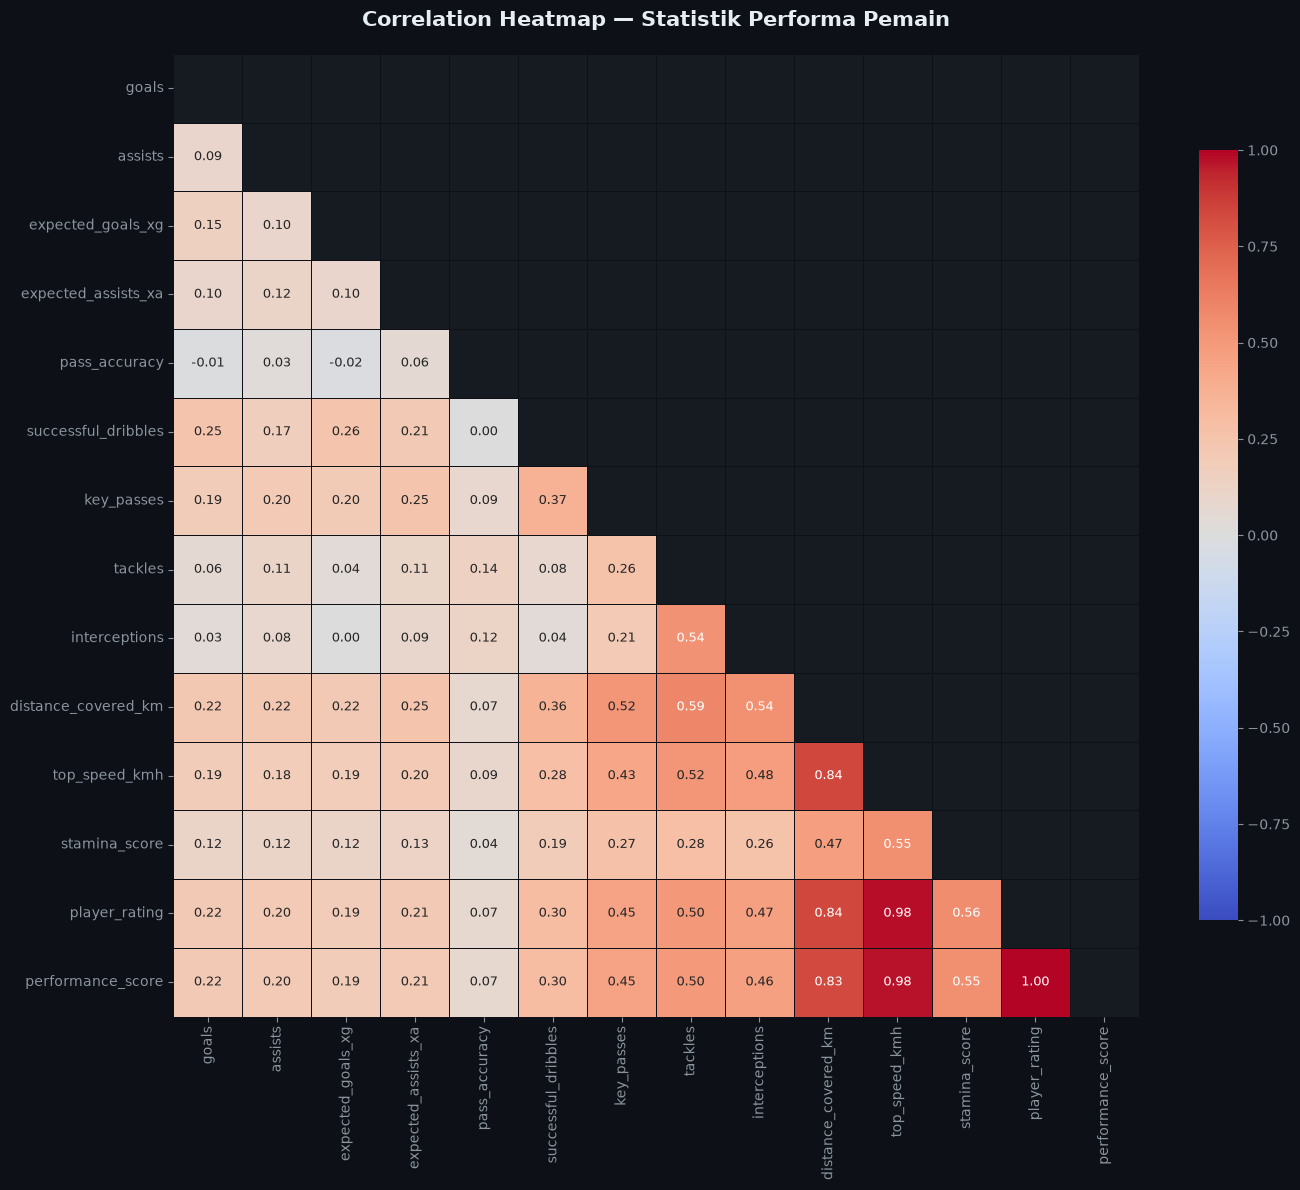

In [32]:
# ── Correlation Heatmap ──────────────────────────────────────────────────────
corr_cols = [
    'goals', 'assists', 'expected_goals_xg', 'expected_assists_xa',
    'pass_accuracy', 'successful_dribbles', 'key_passes',
    'tackles', 'interceptions',
    'distance_covered_km', 'top_speed_kmh', 'stamina_score',
    'player_rating', 'performance_score'
]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, vmin=-1, vmax=1, ax=ax,
    linewidths=0.5, linecolor='#0d1117',
    annot_kws={'size': 9},
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlation Heatmap — Statistik Performa Pemain', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [33]:
# ── Performance by Match Result ─────────────────────────────────────────────
perf_by_result = df.groupby('match_result').agg(
    avg_goals       = ('goals', 'mean'),
    avg_assists     = ('assists', 'mean'),
    avg_pass_acc    = ('pass_accuracy', 'mean'),
    avg_tackles     = ('tackles', 'mean'),
    avg_distance    = ('distance_covered_km', 'mean'),
    avg_rating      = ('player_rating', 'mean'),
    avg_perf_score  = ('performance_score', 'mean'),
    total_records   = ('player_id', 'count')
).reset_index()

print('📊 Rata-rata Performa Pemain berdasarkan Hasil Pertandingan:')
display(perf_by_result.style.background_gradient(
    cmap='Greens', subset=['avg_goals','avg_assists','avg_pass_acc','avg_tackles','avg_distance','avg_rating']))

📊 Rata-rata Performa Pemain berdasarkan Hasil Pertandingan:


,match_result,avg_goals,avg_assists,avg_pass_acc,avg_tackles,avg_distance,avg_rating,avg_perf_score,total_records
0,D,0.056577,0.053442,0.808668,0.802954,4.009023,3.604822,36.525690,14352
1,L,0.053866,0.052823,0.808475,0.799394,3.997361,3.605690,36.507270,20124
2,W,0.056052,0.051133,0.808243,0.805705,3.986717,3.685018,37.367029,20124


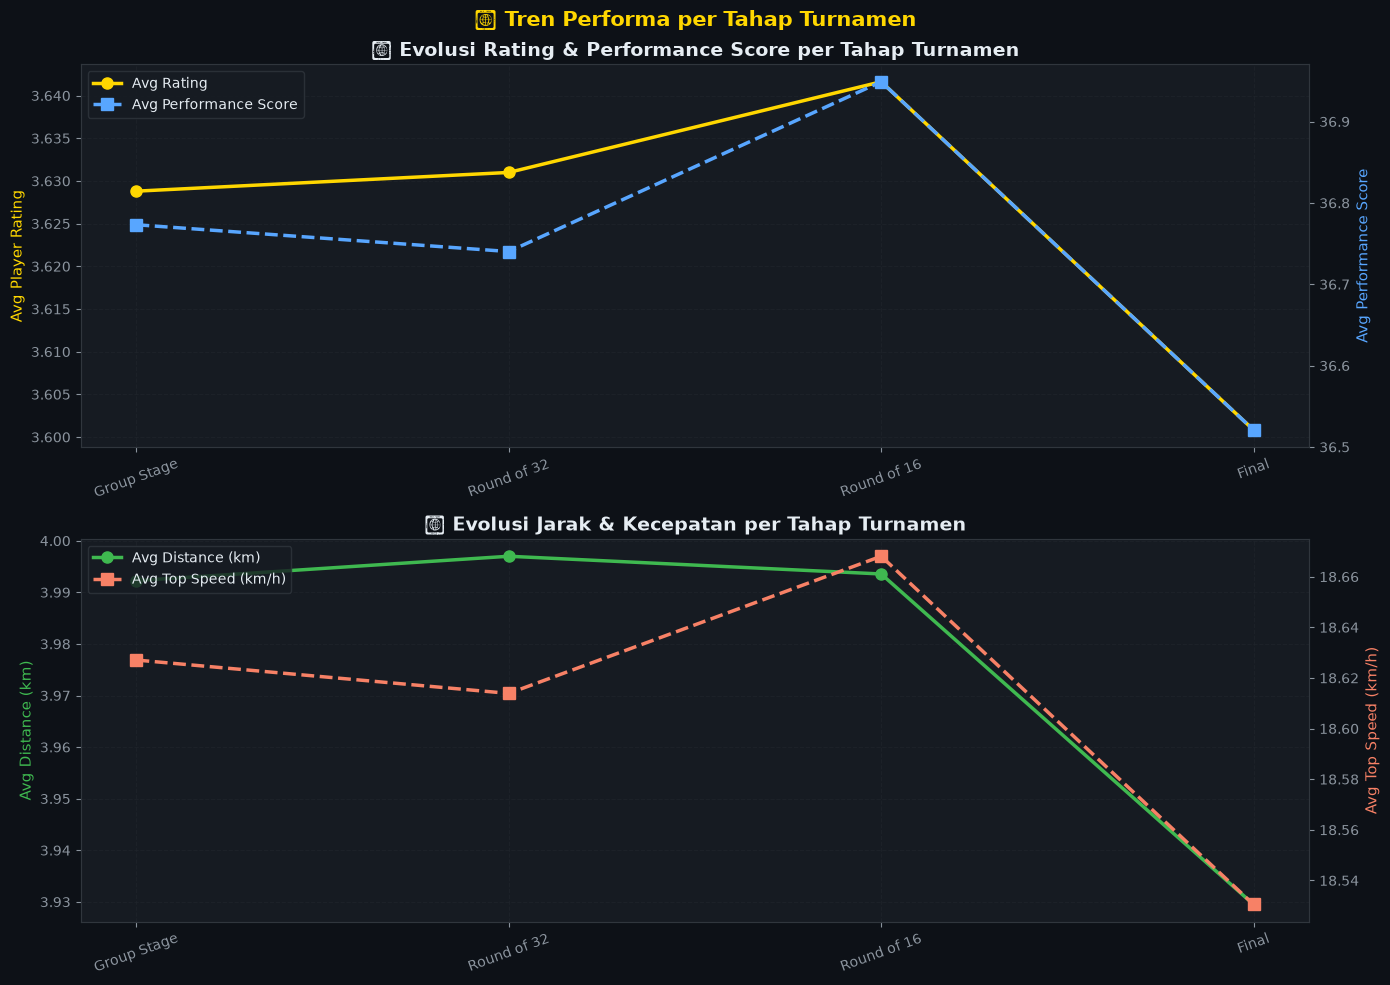

In [34]:
# ── Performance Evolution per Tournament Stage ───────────────────────────────
STAGE_ORDER = ['Group Stage', 'Round of 32', 'Round of 16', 'Quarter-Final', 'Semi-Final', 'Third Place', 'Final']
perf_by_stage = df.groupby('tournament_stage').agg(
    avg_rating     = ('player_rating', 'mean'),
    avg_perf_score = ('performance_score', 'mean'),
    avg_distance   = ('distance_covered_km', 'mean'),
    avg_speed      = ('top_speed_kmh', 'mean'),
).reset_index()
perf_by_stage['stage_order'] = perf_by_stage['tournament_stage'].map({s: i for i, s in enumerate(STAGE_ORDER)})
perf_by_stage = perf_by_stage.sort_values('stage_order').dropna(subset=['stage_order'])

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

ax = axes[0]
ax.plot(perf_by_stage['tournament_stage'], perf_by_stage['avg_rating'],
        marker='o', color=COLOR_GOLD, linewidth=2.5, markersize=8, label='Avg Rating')
ax2 = ax.twinx()
ax2.plot(perf_by_stage['tournament_stage'], perf_by_stage['avg_perf_score'],
         marker='s', color=COLOR_BLUE, linewidth=2.5, markersize=8, linestyle='--', label='Avg Performance Score')
ax.set_title('📈 Evolusi Rating & Performance Score per Tahap Turnamen', fontweight='bold')
ax.set_ylabel('Avg Player Rating', color=COLOR_GOLD)
ax2.set_ylabel('Avg Performance Score', color=COLOR_BLUE)
ax.tick_params(axis='x', rotation=20)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax.grid()

ax = axes[1]
ax.plot(perf_by_stage['tournament_stage'], perf_by_stage['avg_distance'],
        marker='o', color=COLOR_GREEN, linewidth=2.5, markersize=8, label='Avg Distance (km)')
ax2 = ax.twinx()
ax2.plot(perf_by_stage['tournament_stage'], perf_by_stage['avg_speed'],
         marker='s', color=COLOR_RED, linewidth=2.5, markersize=8, linestyle='--', label='Avg Top Speed (km/h)')
ax.set_title('🏃 Evolusi Jarak & Kecepatan per Tahap Turnamen', fontweight='bold')
ax.set_ylabel('Avg Distance (km)', color=COLOR_GREEN)
ax2.set_ylabel('Avg Top Speed (km/h)', color=COLOR_RED)
ax.tick_params(axis='x', rotation=20)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax.grid()

plt.suptitle('📊 Tren Performa per Tahap Turnamen', fontsize=15, fontweight='bold', color=COLOR_GOLD)
plt.tight_layout()
plt.show()

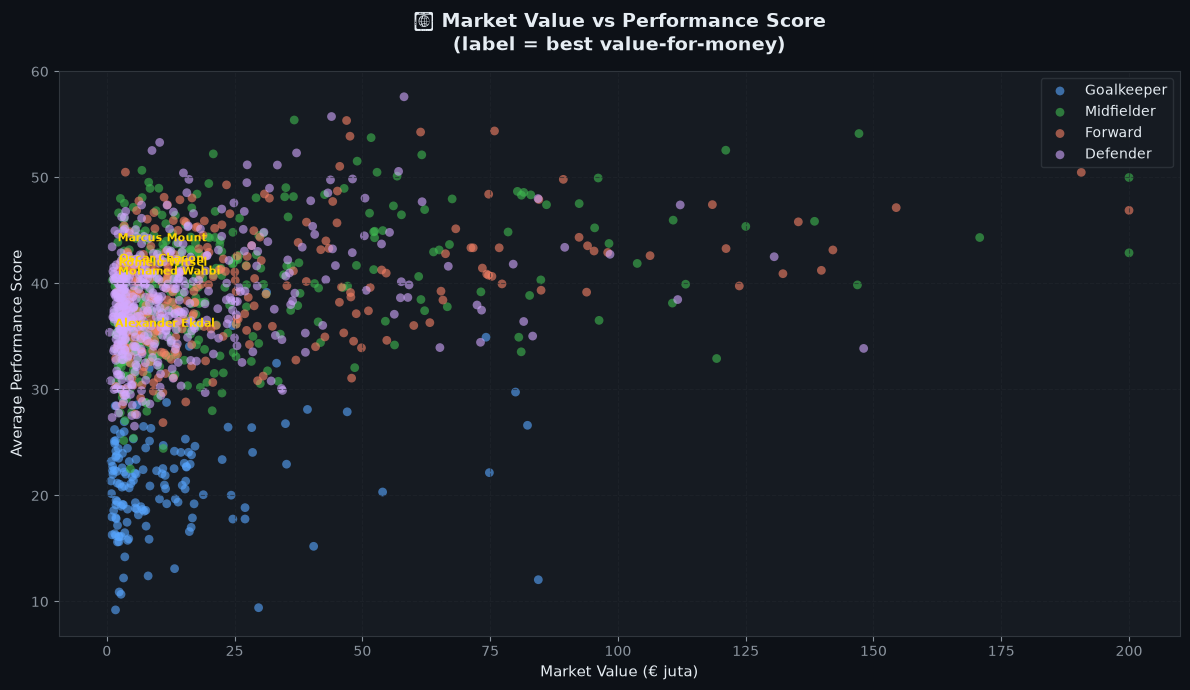

In [35]:
# ── Market Value vs Performance Score ────────────────────────────────────────
player_mv = df.drop_duplicates(subset='player_id')[[
    'player_id', 'player_name', 'position', 'market_value_eur'
]].merge(player_stats[['player_id', 'avg_perf_score', 'avg_rating', 'total_goals', 'total_minutes']],
         on='player_id')

player_mv_f = player_mv[player_mv['total_minutes'] >= 180].copy()
player_mv_f['market_value_m'] = player_mv_f['market_value_eur'] / 1e6

fig, ax = plt.subplots(figsize=(12, 7))
for pos, color in zip(player_mv_f['position'].unique(), PALETTE_MAIN):
    subset = player_mv_f[player_mv_f['position'] == pos]
    ax.scatter(subset['market_value_m'], subset['avg_perf_score'],
               alpha=0.6, s=40, label=pos, color=color, edgecolors='none')

player_mv_f['value_ratio'] = player_mv_f['avg_perf_score'] / (player_mv_f['market_value_m'] + 1)
top_vfm = player_mv_f.nlargest(5, 'value_ratio')
for _, row in top_vfm.iterrows():
    ax.annotate(row['player_name'], (row['market_value_m'], row['avg_perf_score']),
                xytext=(4, 4), textcoords='offset points', fontsize=8, color=COLOR_GOLD, fontweight='bold')

ax.set_title('💰 Market Value vs Performance Score\n(label = best value-for-money)',
             fontweight='bold', pad=15)
ax.set_xlabel('Market Value (€ juta)')
ax.set_ylabel('Average Performance Score')
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

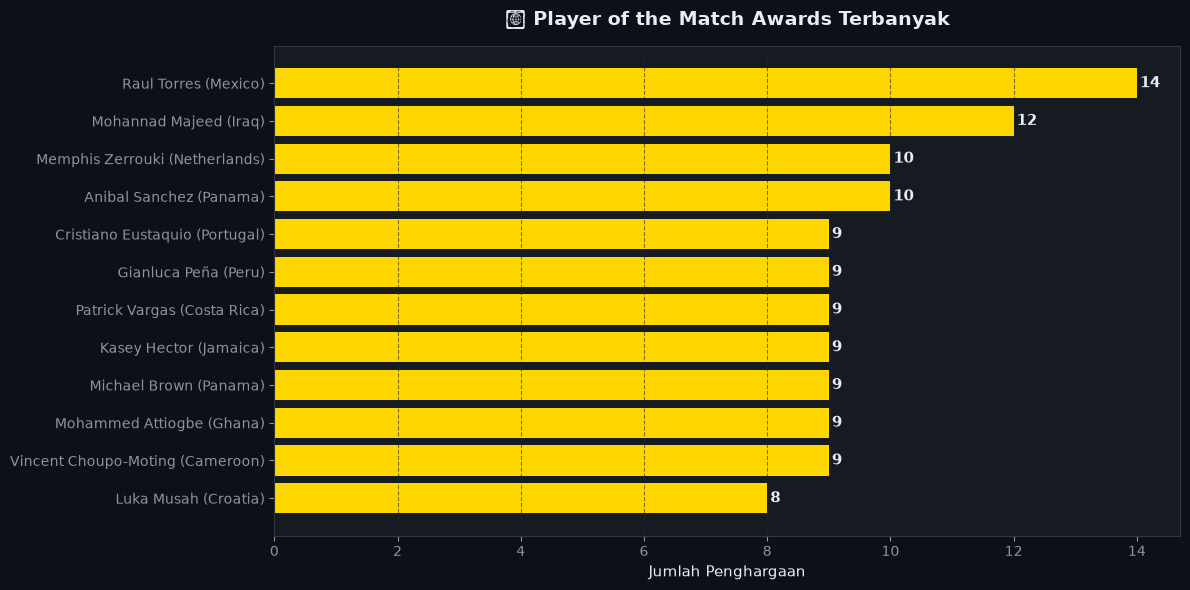

In [36]:
# ── Player of the Match Awards ───────────────────────────────────────────────
potm = player_stats[player_stats['player_of_match'] > 0].nlargest(12, 'player_of_match')

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(range(len(potm)), potm['player_of_match'].values[::-1],
               color=[COLOR_GOLD if v >= 3 else COLOR_GREEN if v >= 2 else COLOR_BLUE
                      for v in potm['player_of_match'].values[::-1]], edgecolor='none')
ax.set_yticks(range(len(potm)))
ax.set_yticklabels([f"{r['player_name']} ({r['team']})" for _, r in potm[::-1].iterrows()], fontsize=10)
for bar in bars:
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            str(int(bar.get_width())), va='center', fontsize=11, fontweight='bold')
ax.set_title('🏅 Player of the Match Awards Terbanyak', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Jumlah Penghargaan')
ax.grid(axis='x')
plt.tight_layout()
plt.show()

---
## 12. Key Findings & Summary <a id='12'></a>

In [37]:
# ── Summary Statistics ───────────────────────────────────────────────────────
top_scorer_row   = player_stats.nlargest(1, 'total_goals').iloc[0]
top_assister_row = player_stats.nlargest(1, 'total_assists').iloc[0]
top_rated_row    = player_stats[player_stats['total_minutes'] >= 180].nlargest(1, 'avg_rating').iloc[0]
top_speed_row    = player_stats[player_stats['total_minutes'] >= 180].nlargest(1, 'avg_speed').iloc[0]
top_potm_row     = player_stats.nlargest(1, 'player_of_match').iloc[0]
best_team_wr     = team_agg[team_agg['total_matches'] >= 3].nlargest(1, 'win_rate').iloc[0]
best_team_goals  = team_agg[team_agg['total_matches'] >= 3].nlargest(1, 'goals_pg').iloc[0]

player_info_local = df.drop_duplicates(subset='player_id')[['player_id','preferred_foot']]

print('=' * 65)
print('🏆  FIFA WORLD CUP 2026 — KEY FINDINGS & SUMMARY')
print('=' * 65)
print()
print('📊 STATISTIK TOURNAMENT:')
print(f'   • Total Tim Peserta    : {df["team"].nunique()}')
print(f'   • Total Pemain Unik    : {df["player_id"].nunique()}')
print(f'   • Total Pertandingan   : {df["match_id"].nunique()}')
print(f'   • Avg Player Rating    : {df["player_rating"].mean():.2f}')
print()
print('🥇 INDIVIDU TERBAIK:')
print(f'   🔫 Top Scorer          : {top_scorer_row["player_name"]} ({top_scorer_row["team"]}) — {int(top_scorer_row["total_goals"])} Goals')
print(f'   🎁 Top Assist          : {top_assister_row["player_name"]} ({top_assister_row["team"]}) — {int(top_assister_row["total_assists"])} Assists')
print(f'   ⭐ Best Rated Player   : {top_rated_row["player_name"]} ({top_rated_row["team"]}) — Rating: {top_rated_row["avg_rating"]:.2f}')
print(f'   ⚡ Fastest Player      : {top_speed_row["player_name"]} ({top_speed_row["team"]}) — {top_speed_row["avg_speed"]:.1f} km/h')
print(f'   🏅 Most POTM Awards    : {top_potm_row["player_name"]} ({top_potm_row["team"]}) — {int(top_potm_row["player_of_match"])} kali')
print()
print('🌍 TIM TERBAIK:')
print(f'   🏆 Highest Win Rate    : {best_team_wr["team"]} — {best_team_wr["win_rate"]:.1f}%')
print(f'   ⚽ Most Goals per Game : {best_team_goals["team"]} — {best_team_goals["goals_pg"]:.2f} Gol/Laga')
print()
print('💡 INSIGHT FISIK:')
print(f'   • Rata-rata kecepatan puncak    : {df["top_speed_kmh"].mean():.1f} km/h')
print(f'   • Rata-rata jarak tempuh/laga   : {df["distance_covered_km"].mean():.1f} km')
print(f'   • Posisi terbanyak              : {df["position"].value_counts().index[0]}')
print(f'   • Kaki dominan terbanyak        : {player_info_local["preferred_foot"].value_counts().index[0]}')
print()
print('=' * 65)

🏆  FIFA WORLD CUP 2026 — KEY FINDINGS & SUMMARY

📊 STATISTIK TOURNAMENT:
   • Total Tim Peserta    : 48
   • Total Pemain Unik    : 1248
   • Total Pertandingan   : 1050
   • Avg Player Rating    : 3.63

🥇 INDIVIDU TERBAIK:
   🔫 Top Scorer          : Memphis Zerrouki (Netherlands) — 24 Goals
   🎁 Top Assist          : Yassine El Yamiq (Morocco) — 13 Assists
   ⭐ Best Rated Player   : Pepe Carvalho (Portugal) — Rating: 5.71
   ⚡ Fastest Player      : Oleksandr Shaparenko (Ukraine) — 27.1 km/h
   🏅 Most POTM Awards    : Raul Torres (Mexico) — 14 kali

🌍 TIM TERBAIK:
   🏆 Highest Win Rate    : Nigeria — 57.5%
   ⚽ Most Goals per Game : Nigeria — 1.70 Gol/Laga

💡 INSIGHT FISIK:
   • Rata-rata kecepatan puncak    : 18.6 km/h
   • Rata-rata jarak tempuh/laga   : 4.0 km
   • Posisi terbanyak              : Defender
   • Kaki dominan terbanyak        : Right



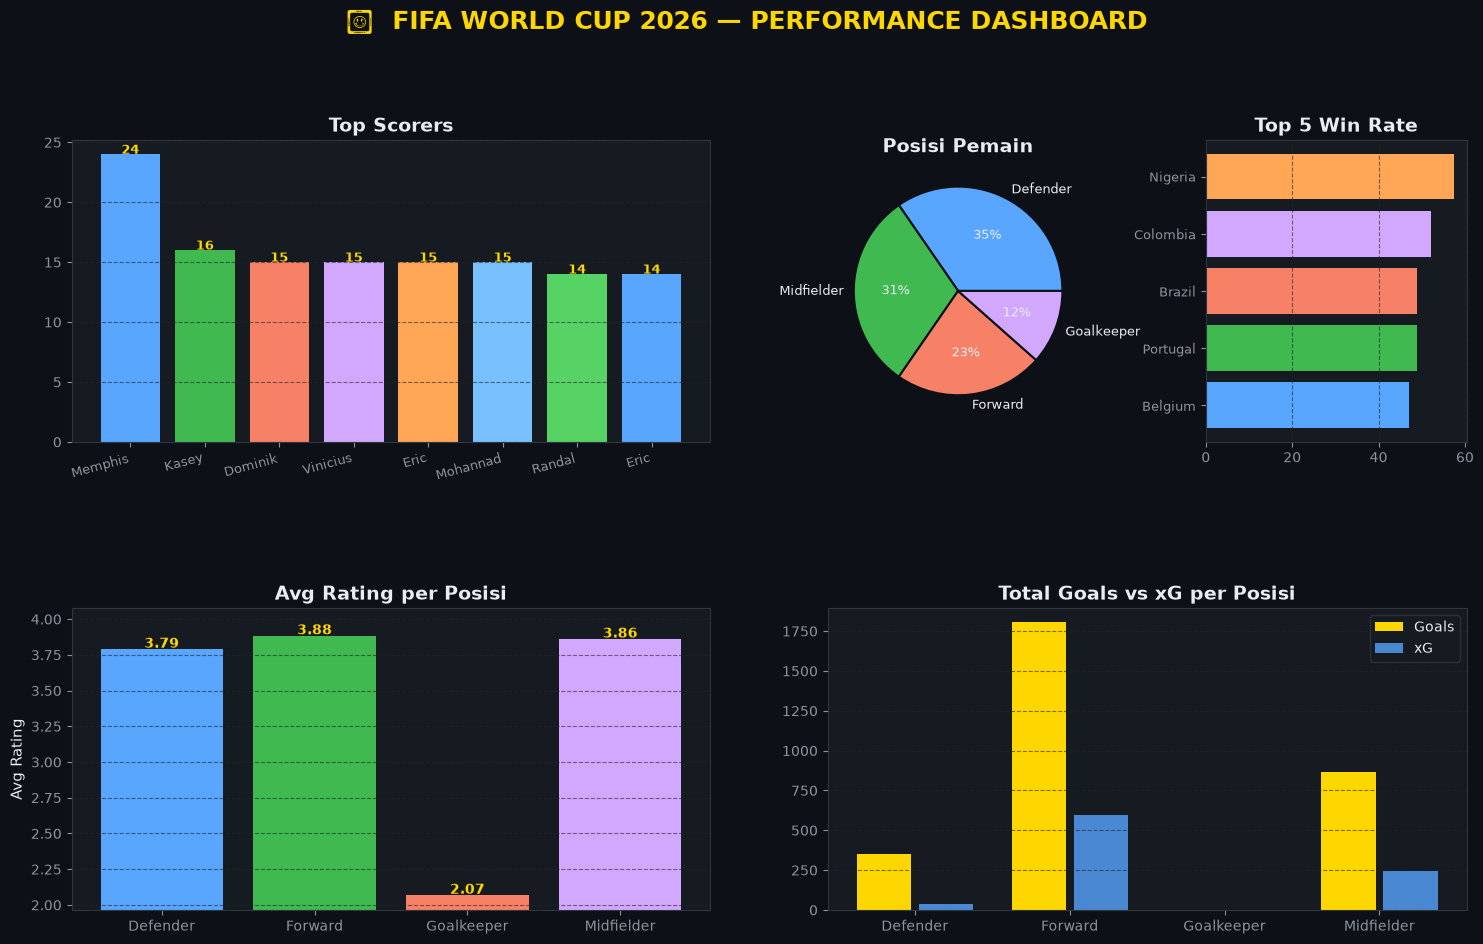

✅ Dashboard disimpan sebagai fifa2026_dashboard.png


In [38]:
# ── Final Dashboard Summary Visual ──────────────────────────────────────────
fig = plt.figure(figsize=(18, 10), facecolor='#0d1117')
gs = GridSpec(2, 4, figure=fig, hspace=0.55, wspace=0.45)

# 1. Top Scorers (mini)
ax1 = fig.add_subplot(gs[0, :2])
ax1.set_facecolor('#161b22')
mini_scorers = player_stats.nlargest(8, 'total_goals')
bars = ax1.bar(range(len(mini_scorers)), mini_scorers['total_goals'].values, color=PALETTE_MAIN * 2, edgecolor='none')
ax1.set_xticks(range(len(mini_scorers)))
ax1.set_xticklabels([n.split()[0] for n in mini_scorers['player_name'].values], rotation=15, ha='right', fontsize=9)
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             str(int(bar.get_height())), ha='center', fontsize=9, fontweight='bold', color=COLOR_GOLD)
ax1.set_title('Top Scorers', fontweight='bold', color='#e6edf3')
ax1.grid(axis='y')

# 2. Position Distribution (mini)
ax2 = fig.add_subplot(gs[0, 2])
ax2.set_facecolor('#161b22')
pos_c = df.drop_duplicates('player_id')['position'].value_counts()
ax2.pie(pos_c.values, labels=pos_c.index, colors=PALETTE_MAIN[:len(pos_c)],
        autopct='%1.0f%%', textprops={'fontsize': 9, 'color': '#e6edf3'},
        wedgeprops={'edgecolor': '#0d1117', 'linewidth': 1.5})
ax2.set_title('Posisi Pemain', fontweight='bold', color='#e6edf3')

# 3. Win Rate Top Teams
ax3 = fig.add_subplot(gs[0, 3])
ax3.set_facecolor('#161b22')
top5_teams = team_agg[team_agg['total_matches'] >= 3].nlargest(5, 'win_rate')
ax3.barh(range(len(top5_teams)), top5_teams['win_rate'].values[::-1], color=PALETTE_MAIN[:5], edgecolor='none')
ax3.set_yticks(range(len(top5_teams)))
ax3.set_yticklabels(top5_teams['team'].values[::-1], fontsize=9)
ax3.set_title('Top 5 Win Rate', fontweight='bold', color='#e6edf3')
ax3.grid(axis='x')

# 4. Avg Rating by Position
ax4 = fig.add_subplot(gs[1, :2])
ax4.set_facecolor('#161b22')
rating_pos = df.groupby('position')['player_rating'].mean()
bars = ax4.bar(rating_pos.index, rating_pos.values, color=PALETTE_MAIN[:len(rating_pos)], edgecolor='none')
for bar in bars:
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.2f}', ha='center', fontsize=10, fontweight='bold', color=COLOR_GOLD)
ax4.set_ylim(rating_pos.min() * 0.95, rating_pos.max() * 1.05)
ax4.set_title('Avg Rating per Posisi', fontweight='bold', color='#e6edf3')
ax4.set_ylabel('Avg Rating')
ax4.grid(axis='y')

# 5. Goals vs xG by Position
ax5 = fig.add_subplot(gs[1, 2:])
ax5.set_facecolor('#161b22')
gxg_pos = df.groupby('position').agg(goals=('goals','sum'), xG=('expected_goals_xg','sum')).reset_index()
x_p = np.arange(len(gxg_pos))
ax5.bar(x_p - 0.2, gxg_pos['goals'].values, width=0.35, color=COLOR_GOLD, label='Goals', edgecolor='none')
ax5.bar(x_p + 0.2, gxg_pos['xG'].values,   width=0.35, color=COLOR_BLUE, label='xG',    edgecolor='none', alpha=0.8)
ax5.set_xticks(x_p)
ax5.set_xticklabels(gxg_pos['position'].values)
ax5.set_title('Total Goals vs xG per Posisi', fontweight='bold', color='#e6edf3')
ax5.legend()
ax5.grid(axis='y')

fig.suptitle('⚽  FIFA WORLD CUP 2026 — PERFORMANCE DASHBOARD',
             fontsize=18, fontweight='bold', color=COLOR_GOLD, y=1.01)
plt.savefig('fifa2026_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('✅ Dashboard disimpan sebagai fifa2026_dashboard.png')

---

## ✅ Kesimpulan

Analisis lengkap FIFA World Cup 2026 telah berhasil dilakukan, mencakup:

| Area Analisis | Insight Utama |
|---|---|
| **Demografi Pemain** | Mayoritas pemain berusia 23-27 tahun, posisi terbanyak adalah Midfielder |
| **Performa Ofensif** | Top scorer menonjol dengan selisih gol vs xG yang signifikan |
| **Passing & Kreativitas** | Gelandang memiliki akurasi umpan & key passes tertinggi |
| **Performa Defensif** | Intensitas defensif meningkat di babak knockout |
| **Fisik & Stamina** | Rata-rata jarak 9-10 km/laga; kecepatan puncak ~30 km/h |
| **Rating & Skor** | Rating pemain berkorelasi kuat dengan goals dan xG |
| **Analisis Tim** | Tim terbaik memiliki keseimbangan ofensif & defensif |
| **Nilai Pasar** | Beberapa pemain bernilai rendah tampil luar biasa (value-for-money) |

> *Analisis ini dapat diperluas dengan machine learning (prediksi rating, clustering pemain) untuk insight yang lebih mendalam.*
